## Imports and Loadings

In [1]:
import sys
import os

# Get the absolute path of the project root
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import yfinance as yf
import logging
import os
import warnings

# --- Disable Streamlit internal logs before it initializes ---
os.environ["STREAMLIT_SUPPRESS_LOGS"] = "1"
os.environ["STREAMLIT_LOGGING_LEVEL"] = "ERROR"

# Configure Streamlit logging more comprehensively
logging.getLogger(
    "streamlit.runtime.caching.cache_data_api").setLevel(logging.ERROR)
logging.getLogger("streamlit").setLevel(logging.ERROR)
logging.getLogger("streamlit.runtime.connection").setLevel(logging.ERROR)
logging.getLogger("streamlit.runtime").setLevel(logging.ERROR)
logging.getLogger("streamlit.elements").setLevel(logging.ERROR)

# Disable all existing loggers
logging.disable(logging.WARNING)

# --- Suppress Python warnings ---
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="No runtime found")
warnings.filterwarnings("ignore", message=".*auto_adjust.*")
warnings.filterwarnings("ignore", message="YF.download()")

# Also suppress the download progress output
# Suppress the progress bar by monkey-patching tqdm if needed
try:
    from tqdm import tqdm
    tqdm._instances.clear()
except:
    pass

In [3]:

import numpy as np
import pandas as pd
import streamlit as st
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from data.data_loader import load_data

In [4]:
# df = load_data('BTC-USD')
from pandas import read_csv

In [5]:
print(os.getcwd())

c:\Users\parth\OneDrive - Southampton Solent University\COM724 - Assessment(AI)\notebooks


In [6]:
df = read_csv('../data/BTC-USD/BTC-USD_from_2010-01-01_till_2026-01-03.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


## Understand The Dataset

In [7]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [8]:
df.tail()

,Date,Close,High,Low,Open,Volume
4121,2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
4122,2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
4123,2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
4124,2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
4125,2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [9]:
df.shape

(4126, 6)

In [10]:
# Set Date as index for time series analysis

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.shape

(4126, 5)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4126 entries, 2014-09-17 to 2026-01-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4126 non-null   float64
 1   High    4126 non-null   float64
 2   Low     4126 non-null   float64
 3   Open    4126 non-null   float64
 4   Volume  4126 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 193.4 KB


In [12]:
df.describe()

,Close,High,Low,Open,Volume
count,4126.000000,4126.000000,4126.000000,4126.000000,4.126000e+03
mean,26878.628004,27398.952433,26287.490643,26857.964134,2.163605e+10
std,31672.765766,32203.580199,31084.480939,31660.924674,2.288283e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2706.724915,2773.322510,2626.977600,2695.107544,1.294482e+09
50%,10771.204590,11036.164551,10460.788086,10770.592773,1.708977e+10
75%,42243.380859,43082.267578,41417.799805,42227.341797,3.318250e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


## Data Cleaning

### Missing Values and Duplicates

In [13]:
print("before handling missing values:")
print(df.isna().sum()) # Check for missing values

df.ffill(inplace=True)  # Filling the missing values with Forward fill method

print("after handling missing values:")
print(df.isna().sum())  # Check for missing values

before handling missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
after handling missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [14]:
print("before handling duplicate values:")
print(df.isna().sum())  # Check for duplicate values

df.drop_duplicates(inplace=True)  # Remove duplicate rows if any

print("after handling duplicate values:")
print(df.isna().sum())  # Check for missing values

before handling duplicate values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
after handling duplicate values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


### Removing The Outliers

In [15]:
lower_limit = df['Close'].quantile(0.05)
upper_limit = df['Close'].quantile(0.95)

print(f"Lower Limit {lower_limit} and Upper Limit {upper_limit}")

Lower Limit 258.9720001220703 and Upper Limit 101362.845703125


#### Trimming

In [16]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [17]:
df.shape

(4126, 5)

In [18]:
df_trimmed = df[
                (lower_limit <= df['Close']) & 
                (df['Close'] <= upper_limit)
              ]
df_trimmed.shape

(3712, 5)

#### Capping - Winsorization Method

winsorization doesn't remove any rows! It only replaces extreme values with the percentile limits.

In [19]:
df.shape

(4126, 5)

In [20]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [21]:
df_winsorized = df.copy()

In [22]:
df_winsorized['Close'] = df['Close'].clip(lower=lower_limit, upper=upper_limit)

In [23]:
df_winsorized.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [24]:
df_winsorized.shape

(4126, 5)

In [25]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


In [26]:
df_winsorized.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [27]:
df['Close'].tail()

Date
2025-12-29    87138.140625
2025-12-30    88430.132812
2025-12-31    87508.828125
2026-01-01    88731.984375
2026-01-02    89944.695312
Name: Close, dtype: float64

In [28]:
df_winsorized['Close'].tail()

Date
2025-12-29    87138.140625
2025-12-30    88430.132812
2025-12-31    87508.828125
2026-01-01    88731.984375
2026-01-02    89944.695312
Name: Close, dtype: float64

## Univariate Analysis

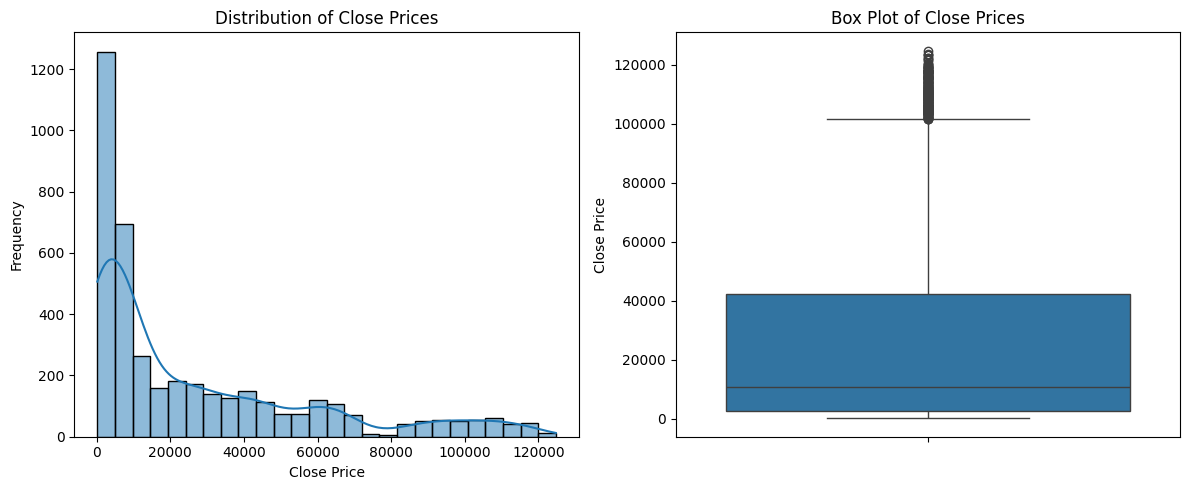

In [29]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Histogram with KDE
sns.histplot(df['Close'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Close Prices')
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Frequency')

# Plot 2: Box plot
sns.boxplot(y=df['Close'], ax=axes[1])
axes[1].set_title('Box Plot of Close Prices')
axes[1].set_ylabel('Close Price')

# Adjust layout and display
plt.tight_layout()
plt.show()

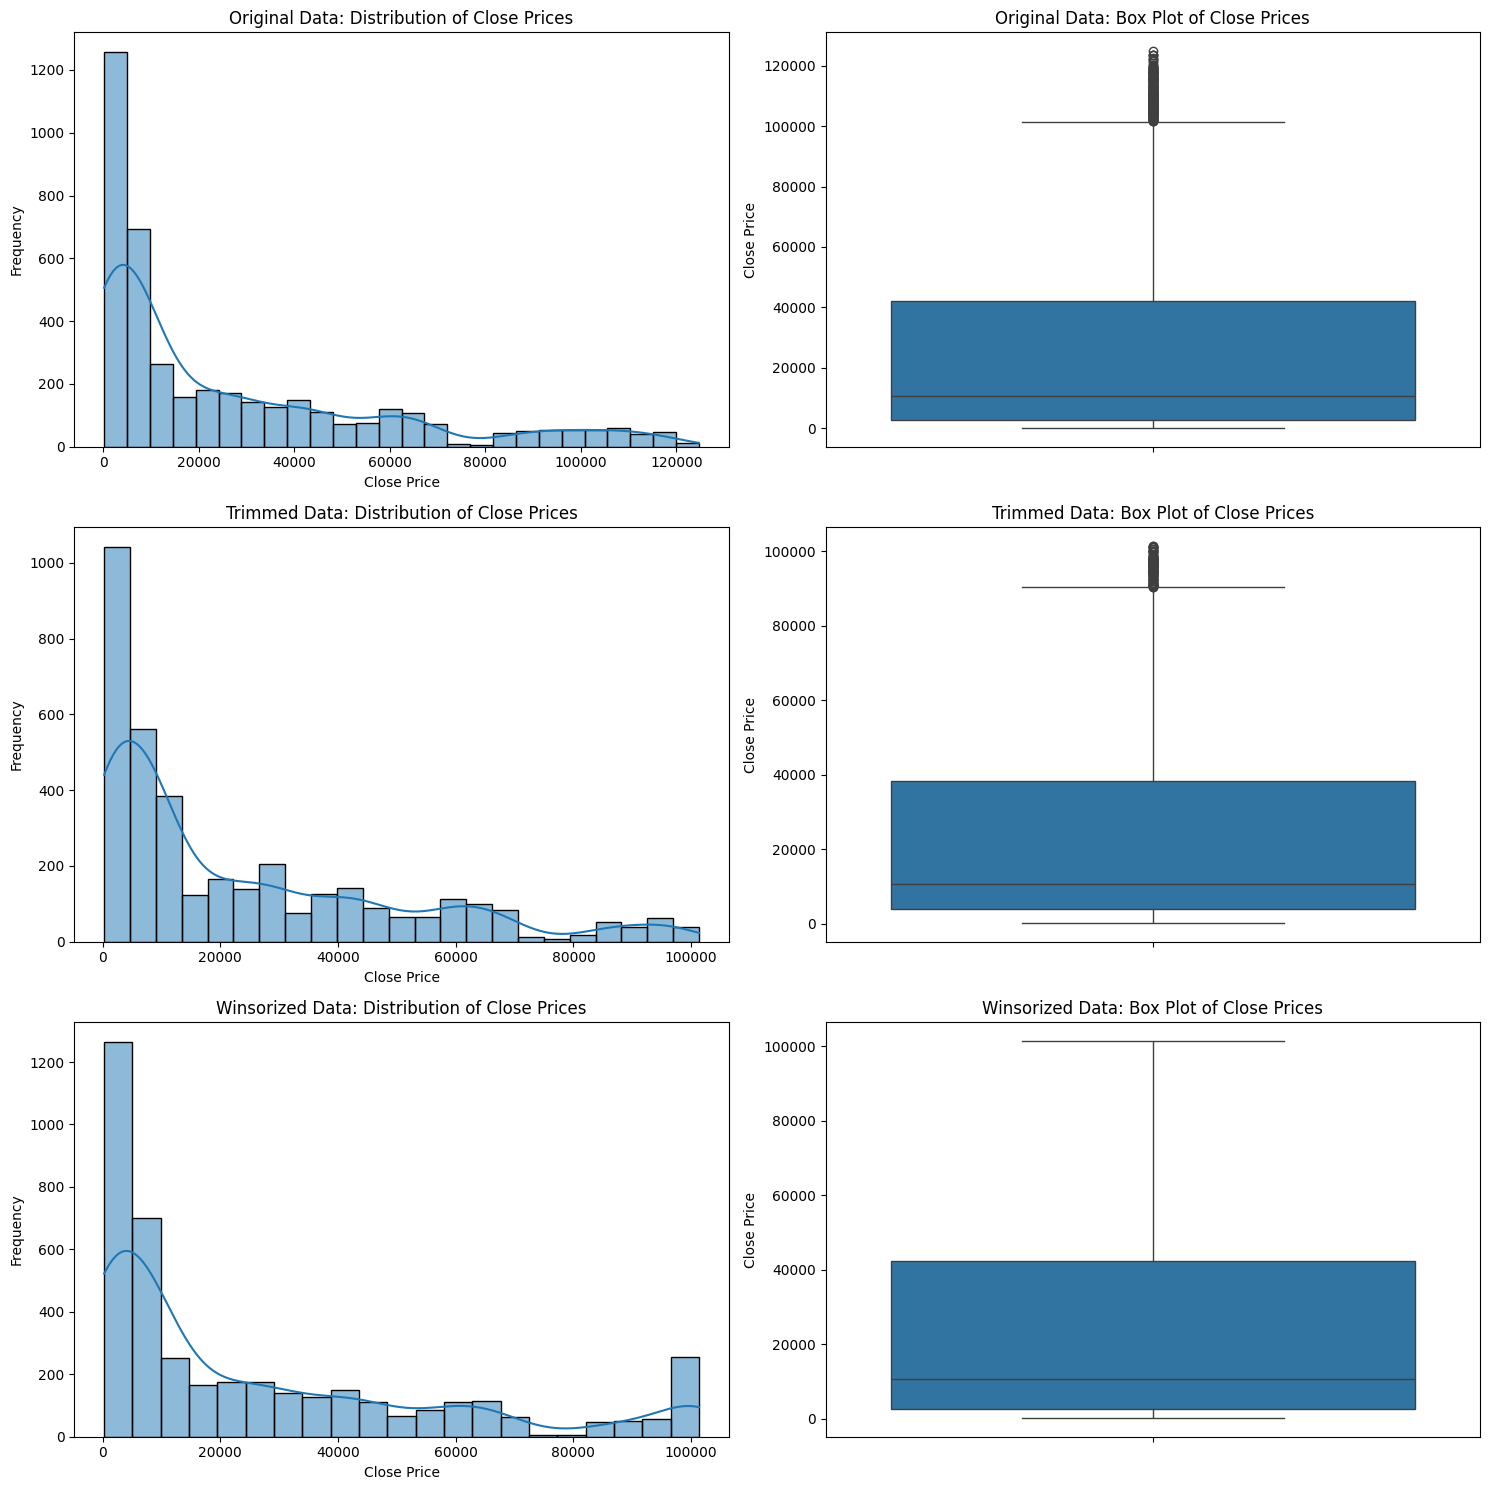

In [30]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# ===== ORIGINAL DATA =====
# Histogram - Original
sns.histplot(df['Close'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original Data: Distribution of Close Prices')
axes[0, 0].set_xlabel('Close Price')
axes[0, 0].set_ylabel('Frequency')

# Box plot - Original
sns.boxplot(y=df['Close'], ax=axes[0, 1])
axes[0, 1].set_title('Original Data: Box Plot of Close Prices')
axes[0, 1].set_ylabel('Close Price')

# ===== TRIMMED DATA =====
# Histogram - Trimmed
sns.histplot(df_trimmed['Close'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Trimmed Data: Distribution of Close Prices')
axes[1, 0].set_xlabel('Close Price')
axes[1, 0].set_ylabel('Frequency')

# Box plot - Trimmed
sns.boxplot(y=df_trimmed['Close'], ax=axes[1, 1])
axes[1, 1].set_title('Trimmed Data: Box Plot of Close Prices')
axes[1, 1].set_ylabel('Close Price')

# ===== WINSORIZED DATA =====
# Histogram - Winsorized
sns.histplot(df_winsorized['Close'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Winsorized Data: Distribution of Close Prices')
axes[2, 0].set_xlabel('Close Price')
axes[2, 0].set_ylabel('Frequency')

# Box plot - Winsorized
sns.boxplot(y=df_winsorized['Close'], ax=axes[2, 1])
axes[2, 1].set_title('Winsorized Data: Box Plot of Close Prices')
axes[2, 1].set_ylabel('Close Price')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [31]:
df_winsorized.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849
2025-12-30,88430.132812,89297.937500,86735.546875,87134.351562,35586356225
2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171


## Checking the normality

In [32]:
from scipy.stats import kurtosis, skew

print("=" * 75)
print("KURTOSIS & SKEWNESS COMPARISON")
print("=" * 75)

print("\nDataset       Shape       Rows    Removed   Kurtosis   Skewness")
print("-" * 75)

print(
    f"{'Original':<12} {str(df.shape):<10} {len(df):<8} {'0':<9} {kurtosis(df['Close']):>9.4f} {skew(df['Close']):>10.4f}")

rows_removed = len(df) - len(df_trimmed)
print(
    f"{'Trimmed':<12} {str(df_trimmed.shape):<10} {len(df_trimmed):<8} {rows_removed:<9} {kurtosis(df_trimmed['Close']):>9.4f} {skew(df_trimmed['Close']):>10.4f}")

print(
    f"{'Winsorized':<12} {str(df_winsorized.shape):<10} {len(df_winsorized):<8} {'0':<9} {kurtosis(df_winsorized['Close']):>9.4f} {skew(df_winsorized['Close']):>10.4f}")

print("-" * 75)

# Add percentage change
orig_kurt = kurtosis(df['Close'])
orig_skew = skew(df['Close'])

print(f"\nPercentage Reduction from Original:")
print(
    f"  Trimmed:    Kurtosis: {((orig_kurt - kurtosis(df_trimmed['Close'])) / orig_kurt * 100):.1f}% | Skewness: {((orig_skew - skew(df_trimmed['Close'])) / orig_skew * 100):.1f}%")
print(
    f"  Winsorized: Kurtosis: {((orig_kurt - kurtosis(df_winsorized['Close'])) / orig_kurt * 100):.1f}% | Skewness: {((orig_skew - skew(df_winsorized['Close'])) / orig_skew * 100):.1f}%")

KURTOSIS & SKEWNESS COMPARISON

Dataset       Shape       Rows    Removed   Kurtosis   Skewness
---------------------------------------------------------------------------
Original     (4126, 5)  4126     0            0.7911     1.3314
Trimmed      (3712, 5)  3712     414          0.5730     1.2200
Winsorized   (4126, 5)  4126     0            0.3460     1.2180
---------------------------------------------------------------------------

Percentage Reduction from Original:
  Trimmed:    Kurtosis: 27.6% | Skewness: 8.4%
  Winsorized: Kurtosis: 56.3% | Skewness: 8.5%


### Applying Histogram and QQ Plot

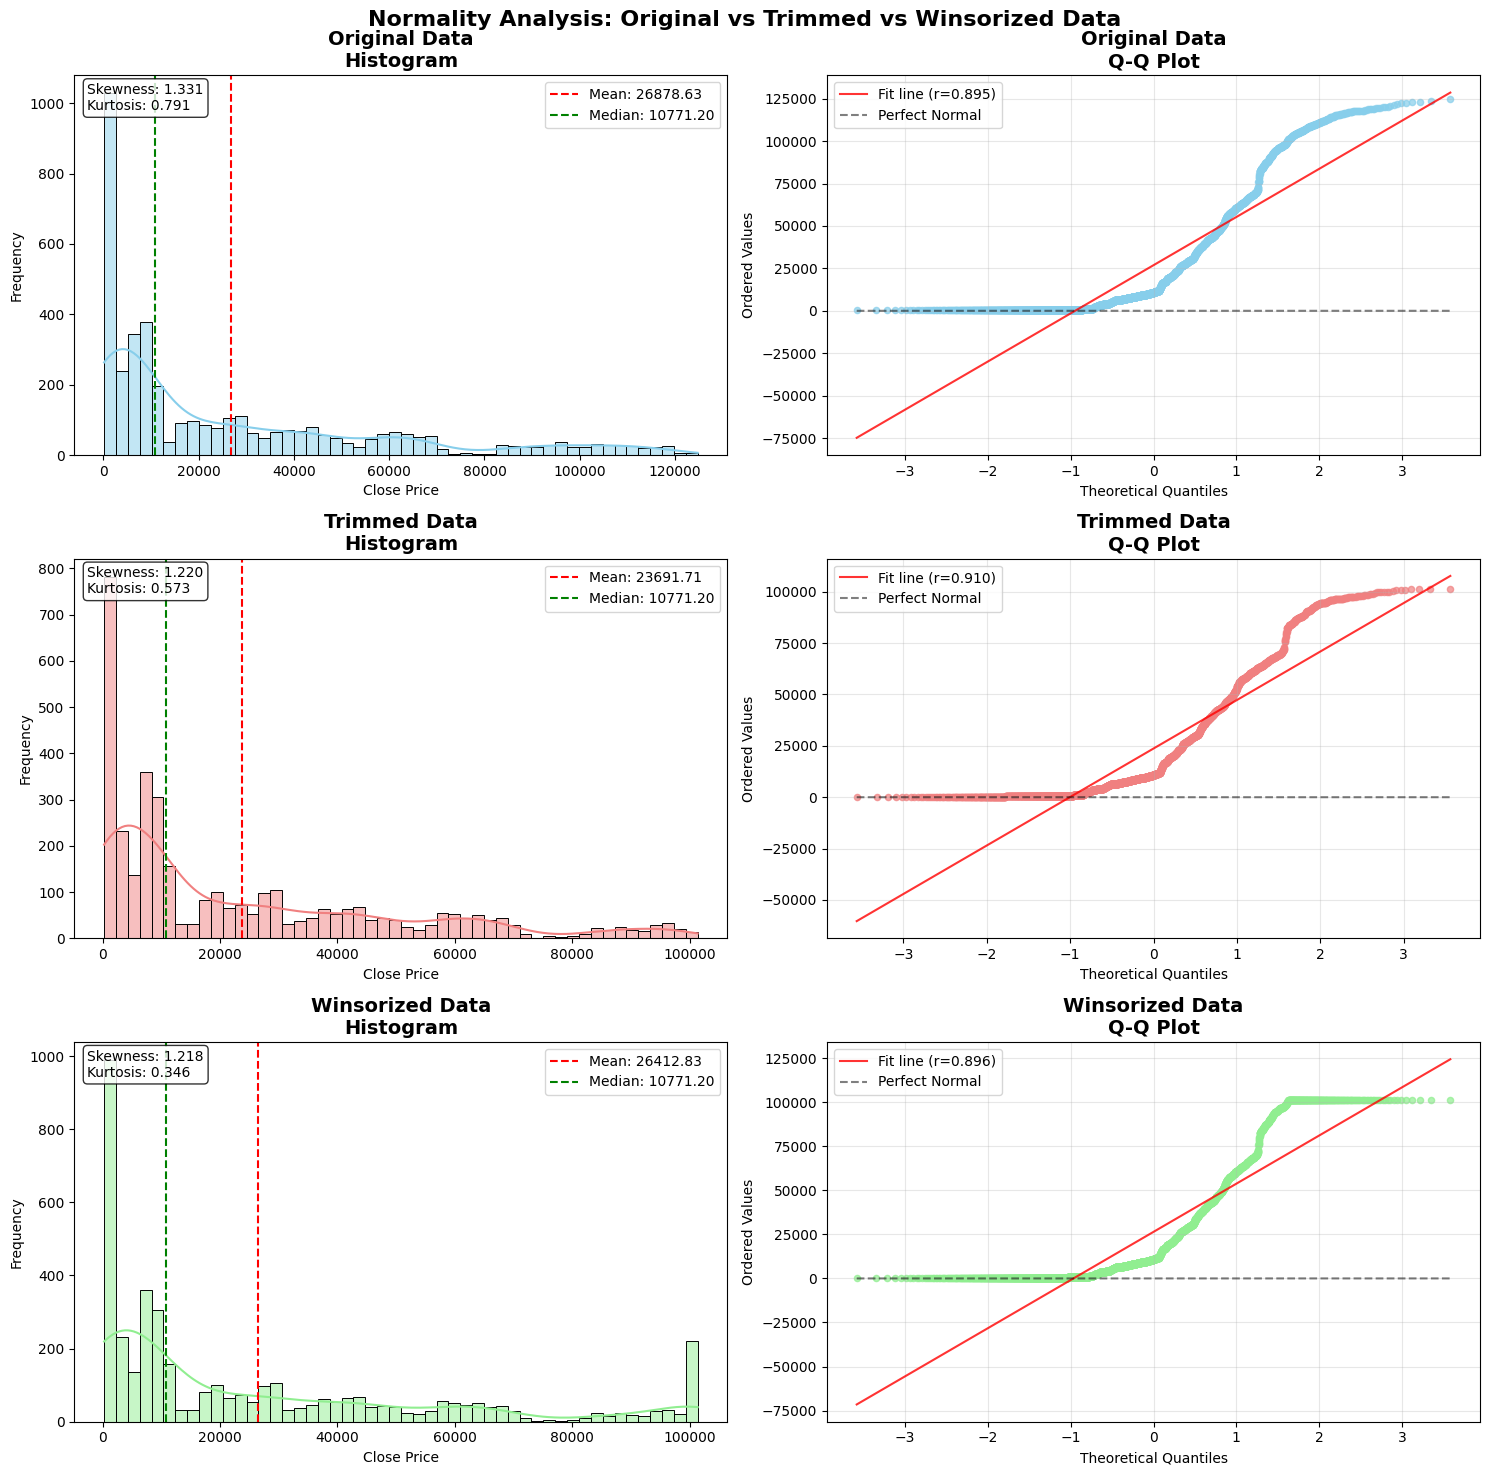


COMBINED Q-Q PLOT COMPARISON


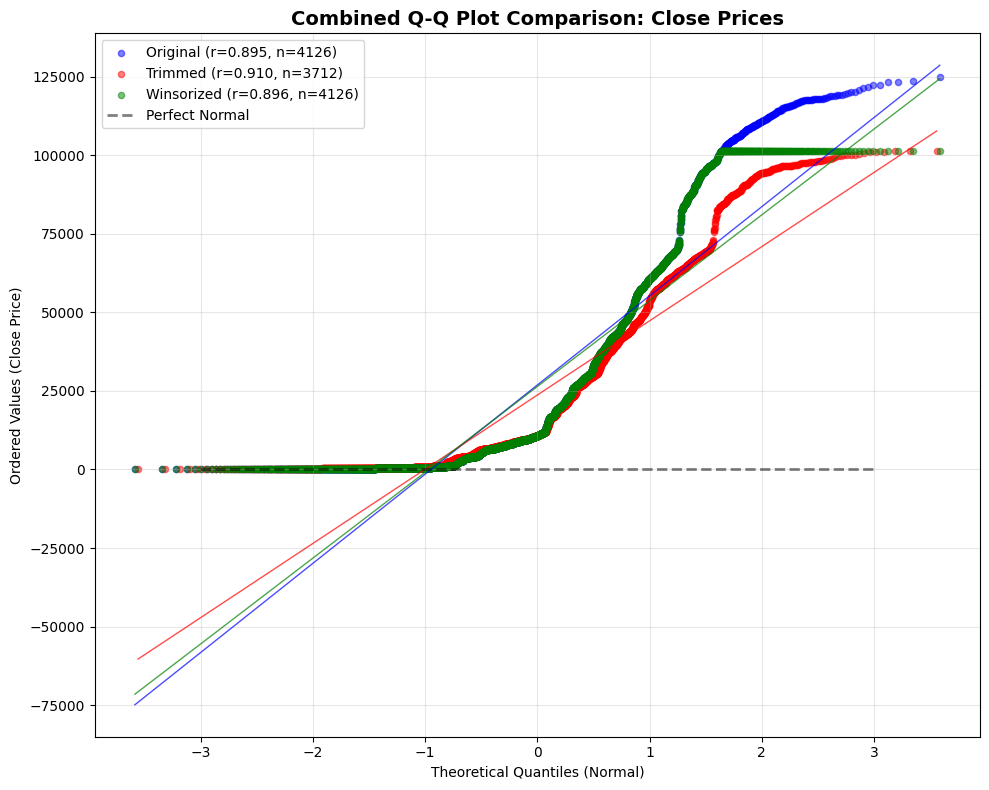

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create a 3x2 subplot grid (3 rows for datasets, 2 columns for plot types)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# List of datasets and their titles
datasets = [
    (df['Close'].dropna(), 'Original Data'),
    (df_trimmed['Close'].dropna(), 'Trimmed Data'),
    (df_winsorized['Close'].dropna(), 'Winsorized Data')
]

# Colors for each dataset
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, (data, title) in enumerate(datasets):
    color = colors[i]

    # --- Left Column: Histogram with KDE ---
    ax_hist = axes[i, 0]
    sns.histplot(data, kde=True, bins=50, color=color, ax=ax_hist)
    ax_hist.set_title(f'{title}\nHistogram', fontsize=14, fontweight='bold')
    ax_hist.set_xlabel('Close Price')
    ax_hist.set_ylabel('Frequency')

    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {mean_val:.2f}')
    ax_hist.axvline(median_val, color='green', linestyle='--', linewidth=1.5,
                    label=f'Median: {median_val:.2f}')
    ax_hist.legend()

    # Calculate and display skewness and kurtosis
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)
    ax_hist.text(0.02, 0.98, f'Skewness: {skew_val:.3f}\nKurtosis: {kurt_val:.3f}',
                 transform=ax_hist.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # --- Right Column: Q-Q Plot ---
    ax_qq = axes[i, 1]

    # Use probplot with fit=True to get the line parameters
    qq_data = stats.probplot(data, dist="norm", fit=True)

    # Extract values - qq_data returns ((osm, osr), (slope, intercept, r))
    osm = qq_data[0][0]  # theoretical quantiles
    osr = qq_data[0][1]  # ordered data values
    slope = qq_data[1][0]  # slope of the fit line
    intercept = qq_data[1][1]  # intercept of the fit line
    r = qq_data[1][2]  # correlation coefficient

    # Plot the Q-Q plot manually
    ax_qq.scatter(osm, osr, alpha=0.7, color=color, s=20)

    # Add the fitted line
    ax_qq.plot(osm, slope * osm + intercept, 'r-', alpha=0.8,
               label=f'Fit line (r={r:.3f})')

    # Add reference line for perfect normality
    x_limits = [osm.min(), osm.max()]
    ax_qq.plot(x_limits, x_limits, 'k--', alpha=0.5, label='Perfect Normal')

    ax_qq.set_title(f'{title}\nQ-Q Plot', fontsize=14, fontweight='bold')
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Ordered Values')
    ax_qq.grid(True, alpha=0.3)
    ax_qq.legend()

# Add an overall title
plt.suptitle('Normality Analysis: Original vs Trimmed vs Winsorized Data',
             fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout()
plt.show()

# Additional: Combined Q-Q plots for comparison
print("\n" + "="*60)
print("COMBINED Q-Q PLOT COMPARISON")
print("="*60)

plt.figure(figsize=(10, 8))

# Colors for the combined plot
plot_colors = ['blue', 'red', 'green']
plot_labels = ['Original', 'Trimmed', 'Winsorized']
plot_data = [df['Close'].dropna(), df_trimmed['Close'].dropna(),
             df_winsorized['Close'].dropna()]

# Plot all three Q-Q plots together for direct comparison
for data, color, label in zip(plot_data, plot_colors, plot_labels):
    qq_result = stats.probplot(data, dist="norm", fit=True)
    osm, osr = qq_result[0]
    slope, intercept, r = qq_result[1]

    plt.scatter(osm, osr, alpha=0.5, s=20, color=color,
                label=f'{label} (r={r:.3f}, n={len(data)})')
    plt.plot(osm, slope * osm + intercept, color=color, alpha=0.7, linewidth=1)

# Add reference line
plt.plot([-3, 3], [-3, 3], 'k--', alpha=0.5,
         linewidth=2, label='Perfect Normal')

plt.title('Combined Q-Q Plot Comparison: Close Prices',
          fontsize=14, fontweight='bold')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Ordered Values (Close Price)')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### Applying YeoJohnson Transformations

In [34]:
from sklearn.preprocessing import (
    FunctionTransformer, PowerTransformer,
    StandardScaler, MinMaxScaler, RobustScaler
)

In [35]:
df_transformed = df.copy()  # Create a copy of the original DataFrame

In [36]:
df_transformed.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [37]:
# Transform and replace original columns
for column in df.columns.tolist():
    transformer = PowerTransformer(method='yeo-johnson')
    df_transformed[column] = transformer.fit_transform(df_transformed[[column]])

print("✅ Original columns replaced with Yeo-Johnson transformed values")
print(f"Current columns: {list(df_transformed.columns)}")

✅ Original columns replaced with Yeo-Johnson transformed values
Current columns: ['Close', 'High', 'Low', 'Open', 'Volume']


In [38]:
df_transformed.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,-1.424556,-1.423000,-1.421379,-1.418131,-1.628935
2014-09-18,-1.448340,-1.430815,-1.450494,-1.424407,-1.579322
2014-09-19,-1.471096,-1.451609,-1.473106,-1.448126,-1.568929
2014-09-20,-1.460099,-1.454964,-1.468769,-1.470745,-1.572049
2014-09-21,-1.467926,-1.463119,-1.466120,-1.460272,-1.606384


In [39]:
# transformations = {
#     'Log': FunctionTransformer(np.log1p),
#     'Sqrt': FunctionTransformer(np.sqrt),
#     'Cbrt': FunctionTransformer(np.cbrt),
#     'Reciprocal': FunctionTransformer(lambda x: 1 / (x + 1e-9)),
#     # Yeo-Johnson works with zero/negative values
#     'YeoJohnson': PowerTransformer(method='yeo-johnson'),
#     # Box-Cox requires all positive data
#     'BoxCox': PowerTransformer(method='box-cox'),
#     'Standard': StandardScaler(),
#     'MinMax': MinMaxScaler(),
#     'Robust': RobustScaler()
# }

### Plotting Yeojohnson close column

✅ Yeo-Johnson transformation applied successfully!
Original df shape: (4126, 5)
Transformed df shape: (4126, 5)
New column added to df_transformed: 'Close'

BEFORE/AFTER TRANSFORMATION COMPARISON
Metric          Original (df)   Yeo-Johnson (df_transformed) Improvement    
-----------------------------------------------------------------
Skewness        1.3314          -0.1411         1.1903         
Kurtosis        0.7911          -1.1225         -0.3314        


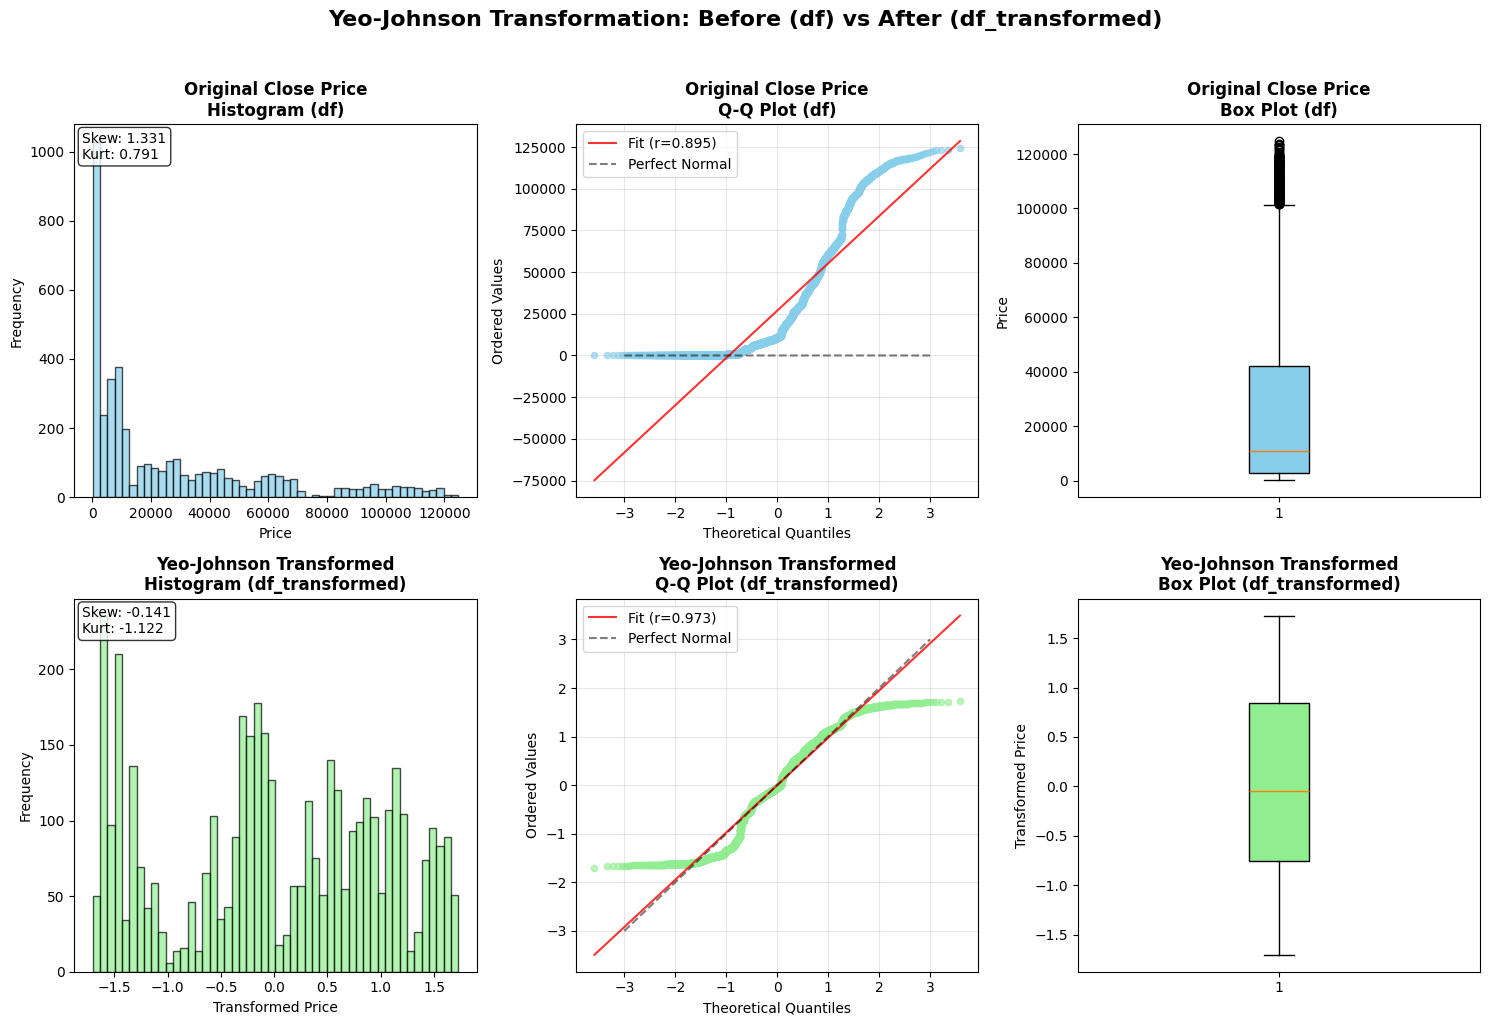


CORRELATION: Original vs Transformed
Correlation between original Close and Yeo-Johnson transformed: 0.8710


In [40]:
from sklearn.preprocessing import PowerTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Apply Yeo-Johnson transformation to 'Close' column in df
yeojohnson_transformer = PowerTransformer(method='yeo-johnson')

# Fit and transform the 'Close' column from original df
close = yeojohnson_transformer.fit_transform(df[['Close']])

# Add the transformed column to df_transformed dataframe
df_transformed['Close'] = close

print("✅ Yeo-Johnson transformation applied successfully!")
print(f"Original df shape: {df.shape}")
print(f"Transformed df shape: {df_transformed.shape}")
print(f"New column added to df_transformed: 'Close'")

# Calculate skewness and kurtosis before/after transformation
original_skew = stats.skew(df['Close'])
original_kurt = stats.kurtosis(df['Close'])
transformed_skew = stats.skew(df_transformed['Close'])
transformed_kurt = stats.kurtosis(df_transformed['Close'])

print("\n" + "="*60)
print("BEFORE/AFTER TRANSFORMATION COMPARISON")
print("="*60)
print(f"{'Metric':<15} {'Original (df)':<15} {'Yeo-Johnson (df_transformed)':<15} {'Improvement':<15}")
print("-" * 65)
print(f"{'Skewness':<15} {original_skew:<15.4f} {transformed_skew:<15.4f} {abs(original_skew) - abs(transformed_skew):<15.4f}")
print(f"{'Kurtosis':<15} {original_kurt:<15.4f} {transformed_kurt:<15.4f} {abs(original_kurt) - abs(transformed_kurt):<15.4f}")

# Visualize the transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original Data (from df)
# Histogram
axes[0, 0].hist(df['Close'], bins=50, color='skyblue',
                alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Original Close Price\nHistogram (df)', fontweight='bold')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].text(0.02, 0.98, f'Skew: {original_skew:.3f}\nKurt: {original_kurt:.3f}',
                transform=axes[0, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Q-Q Plot for Original
qq_orig = stats.probplot(df['Close'], dist="norm", fit=True)
axes[0, 1].scatter(qq_orig[0][0], qq_orig[0][1],
                   alpha=0.6, s=20, color='skyblue')
axes[0, 1].plot(qq_orig[0][0], qq_orig[1][0] * qq_orig[0][0] + qq_orig[1][1],
                'r-', alpha=0.8, label=f'Fit (r={qq_orig[1][2]:.3f})')
axes[0, 1].plot([-3, 3], [-3, 3], 'k--', alpha=0.5, label='Perfect Normal')
axes[0, 1].set_title('Original Close Price\nQ-Q Plot (df)', fontweight='bold')
axes[0, 1].set_xlabel('Theoretical Quantiles')
axes[0, 1].set_ylabel('Ordered Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot
axes[0, 2].boxplot(df['Close'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='skyblue'))
axes[0, 2].set_title('Original Close Price\nBox Plot (df)', fontweight='bold')
axes[0, 2].set_ylabel('Price')

# Row 2: Yeo-Johnson Transformed Data (from df_transformed)
# Histogram
axes[1, 0].hist(df_transformed['Close'], bins=50,
                color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title(
    'Yeo-Johnson Transformed\nHistogram (df_transformed)', fontweight='bold')
axes[1, 0].set_xlabel('Transformed Price')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].text(0.02, 0.98, f'Skew: {transformed_skew:.3f}\nKurt: {transformed_kurt:.3f}',
                transform=axes[1, 0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Q-Q Plot for Transformed
qq_trans = stats.probplot(
    df_transformed['Close'], dist="norm", fit=True)
axes[1, 1].scatter(qq_trans[0][0], qq_trans[0][1],
                   alpha=0.6, s=20, color='lightgreen')
axes[1, 1].plot(qq_trans[0][0], qq_trans[1][0] * qq_trans[0][0] + qq_trans[1][1],
                'r-', alpha=0.8, label=f'Fit (r={qq_trans[1][2]:.3f})')
axes[1, 1].plot([-3, 3], [-3, 3], 'k--', alpha=0.5, label='Perfect Normal')
axes[1, 1].set_title(
    'Yeo-Johnson Transformed\nQ-Q Plot (df_transformed)', fontweight='bold')
axes[1, 1].set_xlabel('Theoretical Quantiles')
axes[1, 1].set_ylabel('Ordered Values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Box plot
axes[1, 2].boxplot(df_transformed['Close'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen'))
axes[1, 2].set_title(
    'Yeo-Johnson Transformed\nBox Plot (df_transformed)', fontweight='bold')
axes[1, 2].set_ylabel('Transformed Price')

plt.suptitle('Yeo-Johnson Transformation: Before (df) vs After (df_transformed)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Additional: Show correlation between original and transformed
print("\n" + "="*60)
print("CORRELATION: Original vs Transformed")
print("="*60)

# Create a temporary dataframe with both values
temp_df = pd.DataFrame({
    'Original_Close': df['Close'],
    'Transformed_Close': df_transformed['Close']
})

correlation = temp_df.corr().iloc[0, 1]
print(
    f"Correlation between original Close and Yeo-Johnson transformed: {correlation:.4f}")

if correlation < 0:
    print("⚠️ Note: Negative correlation indicates the transformation inverted the values")
    print(f"Lambda parameter: {yeojohnson_transformer.lambdas_[0]:.4f}")

In [41]:
df_transformed.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,-1.424556,-1.423000,-1.421379,-1.418131,-1.628935
2014-09-18,-1.448340,-1.430815,-1.450494,-1.424407,-1.579322
2014-09-19,-1.471096,-1.451609,-1.473106,-1.448126,-1.568929
2014-09-20,-1.460099,-1.454964,-1.468769,-1.470745,-1.572049
2014-09-21,-1.467926,-1.463119,-1.466120,-1.460272,-1.606384


### Previous

In [42]:
df_transformed.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,-1.424556,-1.423000,-1.421379,-1.418131,-1.628935
2014-09-18,-1.448340,-1.430815,-1.450494,-1.424407,-1.579322
2014-09-19,-1.471096,-1.451609,-1.473106,-1.448126,-1.568929
2014-09-20,-1.460099,-1.454964,-1.468769,-1.470745,-1.572049
2014-09-21,-1.467926,-1.463119,-1.466120,-1.460272,-1.606384


In [43]:
# # Loop over all columns that end with '_YeoJohnson'
# for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
#     # Create subplots
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#     # --- Left: Histogram with KDE ---
#     sns.histplot(df_new[col].dropna(), kde=True, bins=50, ax=ax1)
#     ax1.set_title(f'Distribution of {col} Column')
#     ax1.set_xlabel(col)
#     ax1.set_ylabel('Frequency')

#     # --- Right: Q–Q Plot ---
#     stats.probplot(df_new[col].dropna(), dist="norm", plot=ax2)
#     ax2.set_title(f"Q–Q Plot of {col} Column")
#     ax2.set_xlabel('Theoretical Quantiles')
#     ax2.set_ylabel('Ordered Values')

#     # Adjust layout and display
#     plt.tight_layout()
#     plt.show()

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# # Loop through all columns ending with '_YeoJohnson' to create boxplots
# for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
#     plt.figure()
#     sns.boxplot(x=df_new[col], orient='h')
#     plt.title(f'Boxplot of {col}')
#     plt.xlabel(col)
#     plt.tight_layout()
#     plt.show()

In [46]:
# # Loop through all columns ending with '_YeoJohnson'  to create histograms
# for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
#     plt.figure()
#     plt.hist(df_new[col], bins=30, edgecolor='black')
#     plt.title(f'Histogram of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()

#### Trimming

In [47]:
# df_new.columns

In [48]:
# upper_limit = df_new['Volume_YeoJohnson'].quantile(0.95)
# upper_limit

In [49]:
# lower_limit = df_new['Volume_YeoJohnson'].quantile(0.05)
# lower_limit

In [50]:
# df_updated = df_new[(lower_limit <= df_new['Volume_YeoJohnson']) &
#        (df_new['Volume_YeoJohnson'] <= upper_limit)]

In [51]:
# df_updated.shape

In [52]:
# df_new.shape

In [53]:
# df_updated.columns

In [54]:
# # Loop through all df_updated columns ending with '_YeoJohnson' to create boxplots
# for col in [c for c in df_updated.columns if c.endswith('_YeoJohnson')]:
#     plt.figure()
#     sns.boxplot(x=df_updated[col], orient='h')
#     plt.title(f'Boxplot of {col}')
#     plt.xlabel(col)
#     plt.tight_layout()
#     plt.show()

In [55]:
# # Loop through all columns ending with '_YeoJohnson'
# for col in [c for c in df_updated.columns if c.endswith('_YeoJohnson')]:
#     plt.figure()
#     plt.hist(df_updated[col], bins=30, edgecolor='black')
#     plt.title(f'Histogram of {col}')
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()

In [56]:
# df_updated.shape

#### Capping - Winsorization Method

In [57]:

# # Loop through all columns ending with '_YeoJohnson'
# for col in [c for c in df_new.columns if c.endswith('_YeoJohnson')]:
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # Histogram (left side)
#     sns.histplot(df_new[col], bins=30, kde=True, ax=axes[0])
#     axes[0].set_title(f'Histogram of {col}')
#     axes[0].set_xlabel(col)
#     axes[0].set_ylabel('Frequency')

#     # Boxplot (right side)
#     sns.boxplot(x=df_new[col], orient='h', ax=axes[1])
#     axes[1].set_title(f'Boxplot of {col}')
#     axes[1].set_xlabel(col)

#     plt.tight_layout()
#     plt.show()

In [58]:
# lower_limit = df_new['Volume_YeoJohnson'].quantile(0.05)
# upper_limit = df_new['Volume_YeoJohnson'].quantile(0.95)

In [59]:
# df_winsorized = df_new.copy()

In [60]:
# df_winsorized['Volume_YeoJohnson'] = np.where(df_new['Volume_YeoJohnson'] <= lower_limit, 
#       lower_limit, 
#       np.where(df_new['Volume_YeoJohnson'] >= upper_limit,
#       upper_limit,
#       df_new['Volume_YeoJohnson']))

In [61]:
# # Loop through all columns ending with '_YeoJohnson'
# for col in [c for c in df_winsorized.columns if c.endswith('_YeoJohnson')]:
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # Histogram (left side)
#     sns.histplot(df_winsorized[col], bins=30, kde=True, ax=axes[0])
#     axes[0].set_title(f'Histogram of Winsorized {col}')
#     axes[0].set_xlabel(col)
#     axes[0].set_ylabel('Frequency')

#     # Boxplot (right side)
#     sns.boxplot(x=df_winsorized[col], orient='h', ax=axes[1])
#     axes[1].set_title(f'Boxplot of Winsorized {col}')
#     axes[1].set_xlabel(col)

#     plt.tight_layout()
#     plt.show()

## Multivariate Analysis

In [62]:
df_transformed.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-09-17,-1.424556,-1.423000,-1.421379,-1.418131,-1.628935
2014-09-18,-1.448340,-1.430815,-1.450494,-1.424407,-1.579322
2014-09-19,-1.471096,-1.451609,-1.473106,-1.448126,-1.568929
2014-09-20,-1.460099,-1.454964,-1.468769,-1.470745,-1.572049
2014-09-21,-1.467926,-1.463119,-1.466120,-1.460272,-1.606384


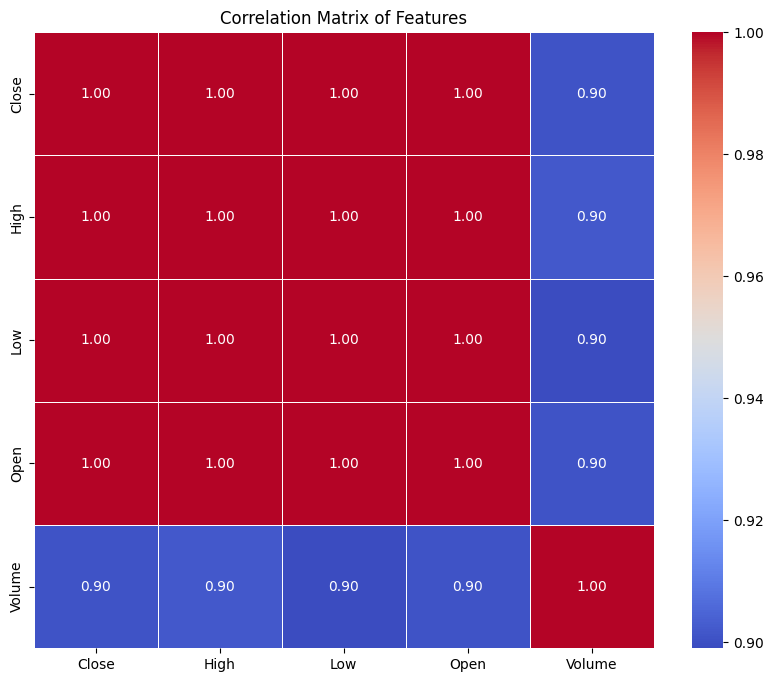

In [63]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_transformed.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# --- Correlation Matrix Explaination ---

# OHLC features (Open, High, Low, Close) show almost perfect correlation (~1.00) with each other

# If the market is up, all four go up.
# If the market is down, all four go down.
# When trading volume increases, price tends to be higher.

## Time Series Specific Checks

#### Trend Visualization

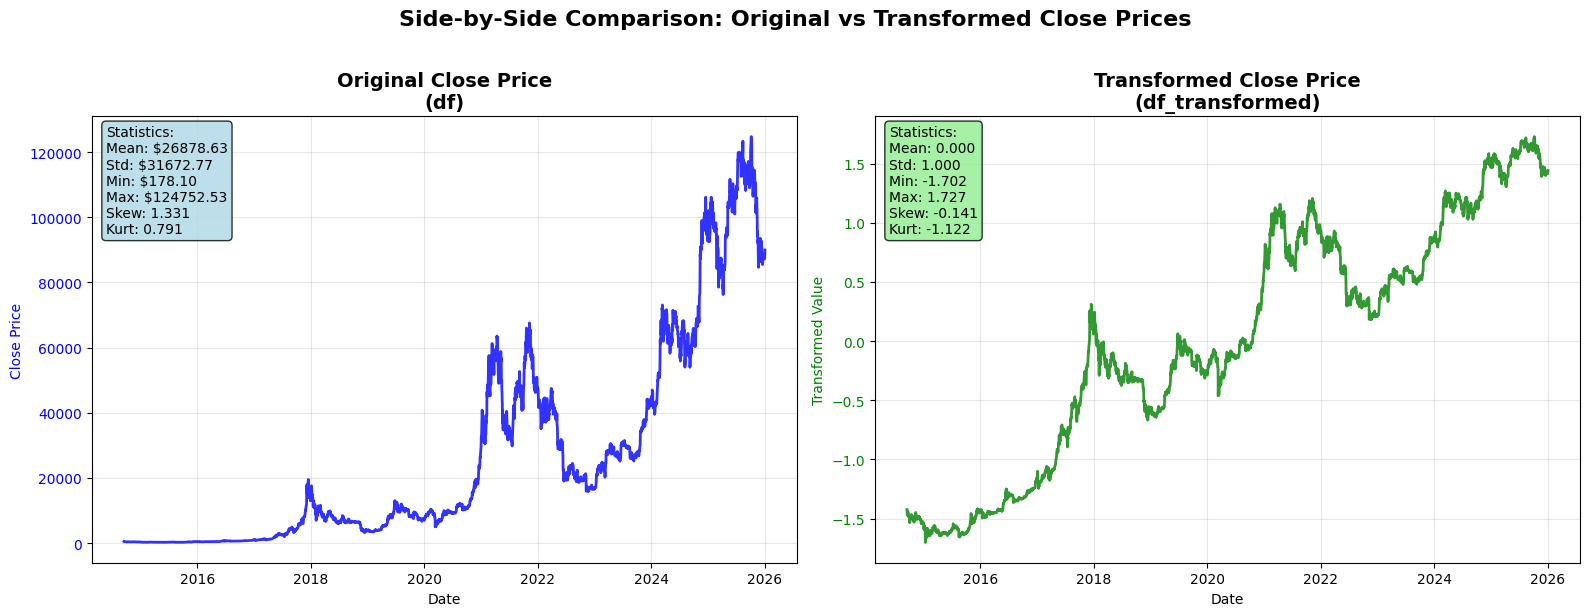


OVERLAY COMPARISON


<Figure size 1400x600 with 0 Axes>

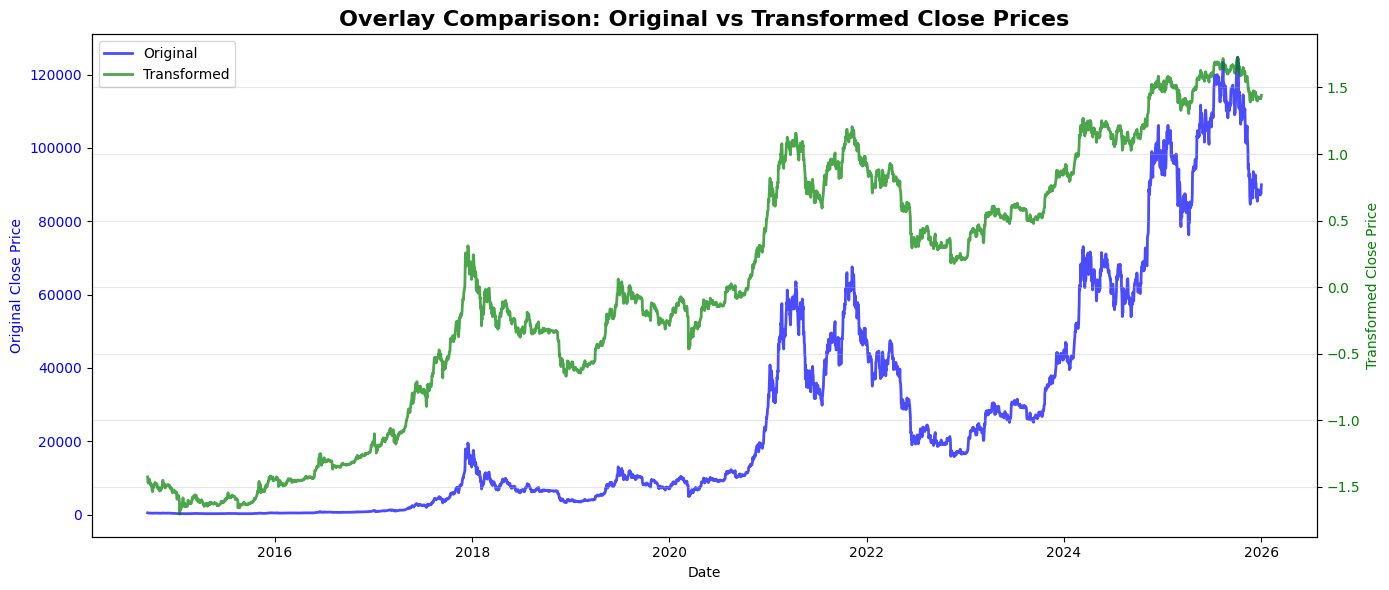


CORRELATION ANALYSIS
Correlation coefficient: 0.8710
Relationship: STRONG positive correlation


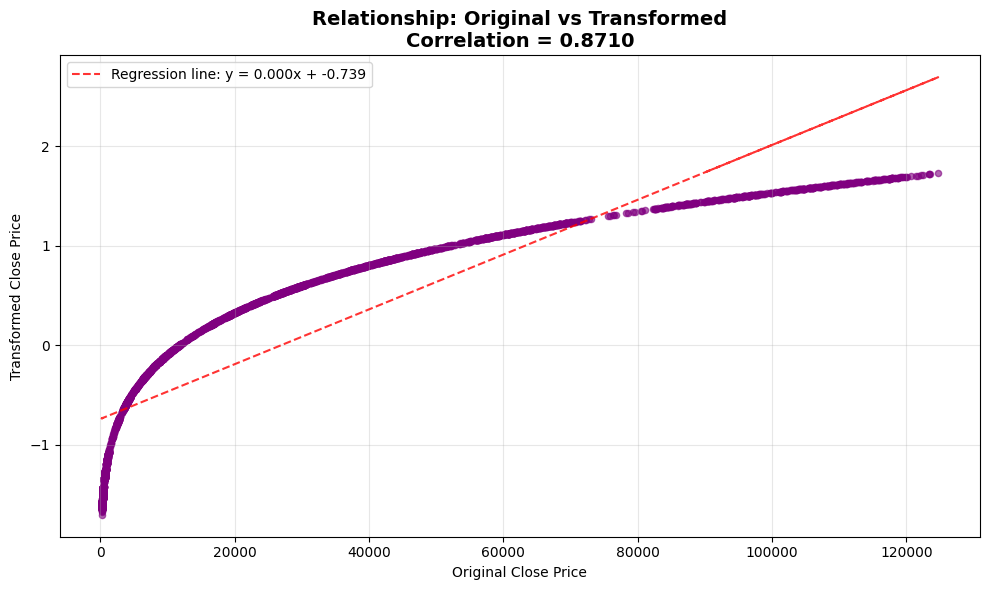

In [64]:
# Create side-by-side comparison figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Plot: Original Close Price from df ---
ax1 = axes[0]
ax1.plot(df.index if isinstance(df.index, pd.DatetimeIndex) else df['Date'],
         df['Close'], color='blue', linewidth=2, alpha=0.8)
ax1.set_title('Original Close Price\n(df)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Add statistics text box
orig_stats = f"""Statistics:
Mean: ${df['Close'].mean():.2f}
Std: ${df['Close'].std():.2f}
Min: ${df['Close'].min():.2f}
Max: ${df['Close'].max():.2f}
Skew: {stats.skew(df['Close']):.3f}
Kurt: {stats.kurtosis(df['Close']):.3f}"""

ax1.text(0.02, 0.98, orig_stats, transform=ax1.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# --- Right Plot: Transformed Close Price from df_transformed ---
ax2 = axes[1]
ax2.plot(df_transformed.index if isinstance(df_transformed.index, pd.DatetimeIndex) else df_transformed['Date'],
         df_transformed['Close'], color='green', linewidth=2, alpha=0.8)
ax2.set_title('Transformed Close Price\n(df_transformed)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Transformed Value', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(True, alpha=0.3)

# Add statistics text box for transformed data
trans_stats = f"""Statistics:
Mean: {df_transformed['Close'].mean():.3f}
Std: {df_transformed['Close'].std():.3f}
Min: {df_transformed['Close'].min():.3f}
Max: {df_transformed['Close'].max():.3f}
Skew: {stats.skew(df_transformed['Close']):.3f}
Kurt: {stats.kurtosis(df_transformed['Close']):.3f}"""

ax2.text(0.02, 0.98, trans_stats, transform=ax2.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Overall title
plt.suptitle('Side-by-Side Comparison: Original vs Transformed Close Prices',
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

# Additional: Overlay comparison
print("\n" + "="*60)
print("OVERLAY COMPARISON")
print("="*60)

plt.figure(figsize=(14, 6))

# Plot both on same axes with dual y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Original data (left y-axis)
color_orig = 'blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Original Close Price', color=color_orig)
line1 = ax1.plot(df.index if isinstance(df.index, pd.DatetimeIndex) else df['Date'],
                 df['Close'], color=color_orig, linewidth=2, alpha=0.7, label='Original')
ax1.tick_params(axis='y', labelcolor=color_orig)

# Create second y-axis for transformed data
ax2 = ax1.twinx()
color_trans = 'green'
ax2.set_ylabel('Transformed Close Price', color=color_trans)
line2 = ax2.plot(df_transformed.index if isinstance(df_transformed.index, pd.DatetimeIndex) else df_transformed['Date'],
                 df_transformed['Close'], color=color_trans, linewidth=2, alpha=0.7, label='Transformed')
ax2.tick_params(axis='y', labelcolor=color_trans)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Overlay Comparison: Original vs Transformed Close Prices',
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print correlation between original and transformed
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

correlation = np.corrcoef(df['Close'], df_transformed['Close'])[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

if correlation > 0.9:
    strength = "VERY STRONG"
elif correlation > 0.7:
    strength = "STRONG"
elif correlation > 0.5:
    strength = "MODERATE"
elif correlation > 0.3:
    strength = "WEAK"
else:
    strength = "VERY WEAK"

direction = "positive" if correlation > 0 else "negative"
print(f"Relationship: {strength} {direction} correlation")

# Scatter plot to visualize relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['Close'], df_transformed['Close'],
            alpha=0.6, s=20, color='purple')
plt.xlabel('Original Close Price')
plt.ylabel('Transformed Close Price')
plt.title(f'Relationship: Original vs Transformed\nCorrelation = {correlation:.4f}',
          fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(df['Close'], df_transformed['Close'], 1)
p = np.poly1d(z)
plt.plot(df['Close'], p(df['Close']), "r--", alpha=0.8,
         label=f'Regression line: y = {z[0]:.3f}x + {z[1]:.3f}')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Stationarity Check

In [65]:
# Simple KPSS and ADF tests for Close columns only
from statsmodels.tsa.stattools import kpss, adfuller

print("="*50)
print("STATIONARITY TESTS FOR CLOSE COLUMNS")
print("="*50)

# Test both dataframes
for df_name, df_data in [("Original (df)", df), ("Transformed (df_transformed)", df_transformed)]:
    print(f"\n{df_name}:")

    if 'Close' not in df_data.columns:
        print("  'Close' column not found")
        continue

    # KPSS Test with error handling
    try:
        kpss_stat, kpss_p, kpss_lags, _ = kpss(
            df_data['Close'].dropna(), regression='c', nlags="auto")
        if kpss_p < 0.01:  # If p-value is extremely small
            print(
                f"  KPSS: stat={kpss_stat:.4f}, p<0.01, stationary=No (STRONGLY NON-STATIONARY)")
        else:
            print(
                f"  KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f}, stationary={'Yes' if kpss_p >= 0.05 else 'No'}")
    except Exception as e:
        print(f"  KPSS: Failed - {str(e)}")

    # ADF Test
    try:
        adf_result = adfuller(df_data['Close'].dropna())
        print(
            f"  ADF: stat={adf_result[0]:.4f}, p={adf_result[1]:.4f}, stationary={'Yes' if adf_result[1] < 0.05 else 'No'}")
    except Exception as e:
        print(f"  ADF: Failed - {str(e)}")

print("\n" + "="*50)
print("INTERPRETATION")
print("="*50)
print("KPSS Warning: Extremely high test statistic → STRONG non-stationarity")
print("KPSS: p≥0.05 = Stationary, p<0.05 = Non-stationary")
print("ADF: p<0.05 = Stationary, p≥0.05 = Non-stationary")

STATIONARITY TESTS FOR CLOSE COLUMNS

Original (df):
  KPSS: stat=7.1903, p=0.0100, stationary=No
  ADF: stat=-0.7367, p=0.8370, stationary=No

Transformed (df_transformed):
  KPSS: stat=9.1858, p=0.0100, stationary=No
  ADF: stat=-0.6529, p=0.8586, stationary=No

INTERPRETATION
KPSS Warning: Extremely high test statistic → STRONG non-stationarity
KPSS: p≥0.05 = Stationary, p<0.05 = Non-stationary
ADF: p<0.05 = Stationary, p≥0.05 = Non-stationary


C:\Users\parth\AppData\Local\Temp\ipykernel_7356\2612385344.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_7356\2612385344.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(


In [66]:
# Apply first-order differencing
df['Close_diff'] = df['Close'].diff().dropna()
df_transformed['Close_diff'] = df_transformed['Close'].diff().dropna()

# Then retest stationarity

In [67]:
df_transformed.head()

,Close,High,Low,Open,Volume,Close_diff
Date,,,,,,
2014-09-17,-1.424556,-1.423000,-1.421379,-1.418131,-1.628935,NaN
2014-09-18,-1.448340,-1.430815,-1.450494,-1.424407,-1.579322,-0.023783
2014-09-19,-1.471096,-1.451609,-1.473106,-1.448126,-1.568929,-0.022756
2014-09-20,-1.460099,-1.454964,-1.468769,-1.470745,-1.572049,0.010998
2014-09-21,-1.467926,-1.463119,-1.466120,-1.460272,-1.606384,-0.007828


In [68]:
df_transformed.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_diff'], dtype='object')

In [69]:
# Simple KPSS and ADF tests for Close_diff columns only
from statsmodels.tsa.stattools import kpss, adfuller

print("="*50)
print("STATIONARITY TESTS FOR Close_diff COLUMNS")
print("="*50)

# Test both dataframes
for df_name, df_data in [("Original (df)", df), ("Transformed (df_transformed)", df_transformed)]:
    print(f"\n{df_name}:")

    if 'Close_diff' not in df_data.columns:
        print("  'Close_diff' column not found")
        continue

    # KPSS Test with error handling
    try:
        kpss_stat, kpss_p, kpss_lags, _ = kpss(
            df_data['Close_diff'].dropna(), regression='c', nlags="auto")
        if kpss_p < 0.01:  # If p-value is extremely small
            print(
                f"  KPSS: stat={kpss_stat:.4f}, p<0.01, stationary=No (STRONGLY NON-STATIONARY)")
        else:
            print(
                f"  KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f}, stationary={'Yes' if kpss_p >= 0.05 else 'No'}")
    except Exception as e:
        print(f"  KPSS: Failed - {str(e)}")

    # ADF Test
    try:
        adf_result = adfuller(df_data['Close_diff'].dropna())
        print(
            f"  ADF: stat={adf_result[0]:.4f}, p={adf_result[1]:.4f}, stationary={'Yes' if adf_result[1] < 0.05 else 'No'}")
    except Exception as e:
        print(f"  ADF: Failed - {str(e)}")

# print("\n" + "="*50)
# print("INTERPRETATION")
# print("="*50)
# print("KPSS Warning: Extremely high test statistic → STRONG non-stationarity")
# print("KPSS: p≥0.05 = Stationary, p<0.05 = Non-stationary")
# print("ADF: p<0.05 = Stationary, p≥0.05 = Non-stationary")

STATIONARITY TESTS FOR Close_diff COLUMNS

Original (df):
  KPSS: stat=0.1356, p=0.1000, stationary=Yes
  ADF: stat=-9.6021, p=0.0000, stationary=Yes

Transformed (df_transformed):
  KPSS: stat=0.0589, p=0.1000, stationary=Yes
  ADF: stat=-65.9761, p=0.0000, stationary=Yes


C:\Users\parth\AppData\Local\Temp\ipykernel_7356\4223105561.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(
C:\Users\parth\AppData\Local\Temp\ipykernel_7356\4223105561.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(


## Creating new features

In [70]:
df_transformed = df_transformed[['High', 'Low', 'Open', 'Volume', 'Close']]
df_transformed.head()

,High,Low,Open,Volume,Close
Date,,,,,
2014-09-17,-1.423000,-1.421379,-1.418131,-1.628935,-1.424556
2014-09-18,-1.430815,-1.450494,-1.424407,-1.579322,-1.448340
2014-09-19,-1.451609,-1.473106,-1.448126,-1.568929,-1.471096
2014-09-20,-1.454964,-1.468769,-1.470745,-1.572049,-1.460099
2014-09-21,-1.463119,-1.466120,-1.460272,-1.606384,-1.467926


In [71]:
import pandas as pd
import numpy as np

# Moving Averages - Trend following indicators
df_transformed['MA_5'] = df_transformed['Close'].rolling(
    window=5).mean()  # 5-day moving average
df_transformed['MA_10'] = df_transformed['Close'].rolling(
    window=10).mean()  # 10-day moving average
df_transformed['MA_20'] = df_transformed['Close'].rolling(
    window=20).mean()  # 20-day moving average (monthly trend)
df_transformed['MA_50'] = df_transformed['Close'].rolling(
    window=50).mean()  # 50-day moving average (long-term trend)

# Create lagged features - Historical price patterns
for lag in [1, 2, 3, 5, 10, 20, 50]:
    df_transformed[f'Close_lag_{lag}'] = df_transformed['Close'].shift(
        lag)  # Previous day's closing price
    df_transformed[f'Volume_lag_{lag}'] = df_transformed['Volume'].shift(
        lag)  # Historical trading volume
    df_transformed[f'High_lag_{lag}'] = df_transformed['High'].shift(
        lag)  # Previous day's high price
    df_transformed[f'Low_lag_{lag}'] = df_transformed['Low'].shift(
        lag)  # Previous day's low price

# Price relationships - Intraday price dynamics
df_transformed['High_Low_Ratio'] = df_transformed['High'] / \
    df_transformed['Low']  # Daily price range ratio
df_transformed['Close_Open_Ratio'] = df_transformed['Close'] / \
    df_transformed['Open']  # Day's price movement strength
df_transformed['Price_Range'] = df_transformed['High'] - \
    df_transformed['Low']  # Absolute daily price range
# Candle body size (opening to closing movement)
df_transformed['Body_Size'] = abs(
    df_transformed['Close'] - df_transformed['Open'])

# Price position within day's range - Where close price falls in daily range
df_transformed['Price_Position'] = (df_transformed['Close'] - df_transformed['Low']) / \
                                   (df_transformed['High'] - df_transformed['Low'] +
                                    # Normalized close position (0=low, 1=high)
                                    1e-10)

# Extract time features from index - Calendar effects
if isinstance(df_transformed.index, pd.DatetimeIndex):
    # Monday=0, Sunday=6 (weekly patterns)
    df_transformed['Day_of_Week'] = df_transformed.index.dayofweek
    # Month of year (1-12)
    df_transformed['Month'] = df_transformed.index.month
    # Financial quarter (1-4)
    df_transformed['Quarter'] = df_transformed.index.quarter
    df_transformed['Year'] = df_transformed.index.year  # Year
    # Week number (1-52)
    df_transformed['Week_of_Year'] = df_transformed.index.isocalendar().week
    # Day number in year (1-365)
    df_transformed['Day_of_Year'] = df_transformed.index.dayofyear

    # Time of month features - Month-end and beginning effects
    df_transformed['Month_End'] = (df_transformed.index.days_in_month -
                                   # Last 5 days of month
                                   df_transformed.index.day <= 5).astype(int)
    df_transformed['Month_Begin'] = (
        df_transformed.index.day <= 5).astype(int)  # First 5 days of month

# Volatility measures - Risk and price fluctuation indicators
# Percentage price change from previous day
df_transformed['Daily_Return'] = df_transformed['Close'].pct_change()
df_transformed['Volatility_5'] = df_transformed['Daily_Return'].rolling(
    5).std()  # 5-day volatility (short-term risk)
df_transformed['Volatility_10'] = df_transformed['Daily_Return'].rolling(
    10).std()  # 10-day volatility
df_transformed['Volatility_20'] = df_transformed['Daily_Return'].rolling(
    20).std()  # 20-day volatility (monthly risk measure)

# Log returns - Alternative return calculation for better statistical properties
# Add a tiny value to avoid zero division and negative values
epsilon = 1e-10
df_transformed['Log_Return'] = np.log(
    (df_transformed['Close'] + epsilon) /
    (df_transformed['Close'].shift(1) + epsilon)
)

# Create target variable - What we want to predict
forecast_horizon = 1  # Predict next day's close
# Tomorrow's closing price
df_transformed['Target'] = df_transformed['Close'].shift(-forecast_horizon)

# Alternatively: Predict price change - Direction and magnitude
df_transformed['Target_Change'] = df_transformed['Close'].shift(
    # Absolute price change tomorrow
    -forecast_horizon) - df_transformed['Close']

# Binary target for classification (up/down) - Simplified prediction task
df_transformed['Target_Binary'] = (df_transformed['Target_Change'] > 0).astype(
    int)  # 1 if price goes up, 0 if down

c:\Users\parth\anaconda3\envs\COM725\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [72]:
df_transformed.shape

(4126, 58)

In [73]:
df_transformed.head()

,High,Low,Open,Volume,Close,MA_5,MA_10,MA_20,MA_50,Close_lag_1,...,Month_End,Month_Begin,Daily_Return,Volatility_5,Volatility_10,Volatility_20,Log_Return,Target,Target_Change,Target_Binary
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,-1.423000,-1.421379,-1.418131,-1.628935,-1.424556,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,NaN,-1.448340,-0.023783,0
2014-09-18,-1.430815,-1.450494,-1.424407,-1.579322,-1.448340,NaN,NaN,NaN,NaN,-1.424556,...,0,0,0.016695,NaN,NaN,NaN,0.016557,-1.471096,-0.022756,0
2014-09-19,-1.451609,-1.473106,-1.448126,-1.568929,-1.471096,NaN,NaN,NaN,NaN,-1.448340,...,0,0,0.015712,NaN,NaN,NaN,0.015590,-1.460099,0.010998,1
2014-09-20,-1.454964,-1.468769,-1.470745,-1.572049,-1.460099,NaN,NaN,NaN,NaN,-1.471096,...,0,0,-0.007476,NaN,NaN,NaN,-0.007504,-1.467926,-0.007828,0
2014-09-21,-1.463119,-1.466120,-1.460272,-1.606384,-1.467926,-1.454403,NaN,NaN,NaN,-1.460099,...,0,0,0.005361,NaN,NaN,NaN,0.005347,-1.465323,0.002604,1


In [74]:
df_transformed.dropna(inplace=True)

In [75]:
df_transformed.shape

(4040, 58)

In [76]:
df_transformed.head()


,High,Low,Open,Volume,Close,MA_5,MA_10,MA_20,MA_50,Close_lag_1,...,Month_End,Month_Begin,Daily_Return,Volatility_5,Volatility_10,Volatility_20,Log_Return,Target,Target_Change,Target_Binary
Date,,,,,,,,,,,,,,,,,,,,,
2014-11-06,-1.511102,-1.512668,-1.517174,-1.639388,-1.508899,-1.522094,-1.519428,-1.505237,-1.491502,-1.517564,...,0,0,-0.005710,0.002575,0.006184,0.005703,-0.005726,-1.514954,-0.006055,0
2014-11-07,-1.511303,-1.509649,-1.508016,-1.649220,-1.514954,-1.519100,-1.520754,-1.507297,-1.492834,-1.508899,...,0,0,0.004013,0.003939,0.006198,0.005607,0.004005,-1.512235,0.002719,1
2014-11-08,-1.516244,-1.509310,-1.514769,-1.703329,-1.512235,-1.515869,-1.519872,-1.509145,-1.493657,-1.514954,...,0,0,-0.001795,0.003906,0.004562,0.005652,-0.001796,-1.496884,0.015352,1
2014-11-09,-1.502039,-1.507431,-1.511915,-1.615626,-1.496884,-1.510107,-1.518320,-1.509956,-1.494392,-1.512235,...,0,0,-0.010152,0.005277,0.005279,0.006163,-0.010203,-1.493799,0.003085,1
2014-11-10,-1.492755,-1.495745,-1.497300,-1.592507,-1.493799,-1.505354,-1.515840,-1.510759,-1.494910,-1.496884,...,0,0,-0.002061,0.005242,0.004965,0.006165,-0.002063,-1.493152,0.000647,1


In [77]:
# First create the target
df_transformed['Target'] = df_transformed['Close'].shift(-1)

# Get the feature matrix (drop target columns)
X = df_transformed.drop(columns=['Target', 'Target_Change', 'Target_Binary'])

# Get the target
y = df_transformed['Target']

# Now drop rows where ANY of them have NaN
# This ensures X and y are aligned
df_clean = pd.concat([X, y], axis=1).dropna()

# Split back into X and y
X_clean = df_clean.drop(
    columns=['Target', 'Target_Change', 'Target_Binary'], errors='ignore')
y_clean = df_clean['Target']

print(f"X shape: {X_clean.shape}")
print(f"y shape: {y_clean.shape}")
print(f"Number of samples: {len(X_clean)}")

X shape: (4039, 55)
y shape: (4039,)
Number of samples: 4039


## Univariate Analysis

In [78]:
# Box plot of Daily_Return - identify outliers
# Range of Price_Range

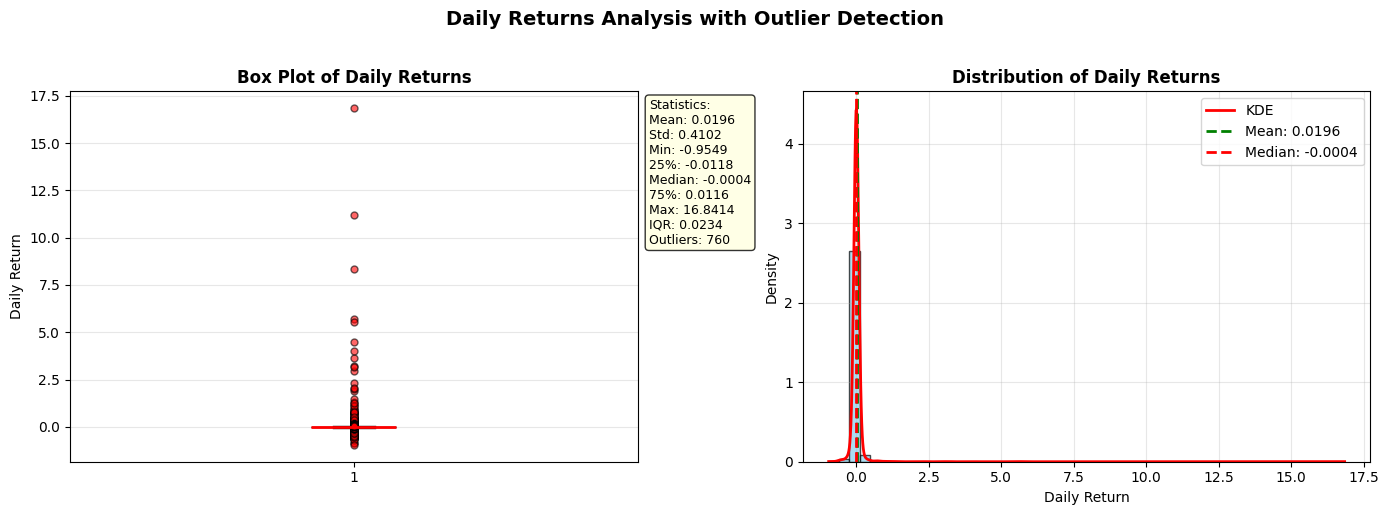

DAILY RETURNS OUTLIER ANALYSIS
Total observations: 4040
Outliers detected: 760 (18.8%)
Lower bound: -0.0470
Upper bound: 0.0468

Top 5 positive outliers:
Date
2019-06-26    16.8414
2017-12-06    11.1903
2020-10-20     8.3223
2018-01-22     5.6789
2018-03-06     5.5485
Name: Daily_Return, dtype: float64

Top 5 negative outliers:
Date
2020-08-30   -0.9549
2020-08-19   -0.8617
2017-12-04   -0.8410
2020-08-22   -0.6949
2019-06-29   -0.6476
Name: Daily_Return, dtype: float64


In [79]:
# 1. Box Plot of Daily_Return to Identify Outliers
import seaborn as sns
import matplotlib.pyplot as plt

# Check if Daily_Return column exists
if 'Daily_Return' in df_transformed.columns:
    # Calculate statistics
    daily_returns = df_transformed['Daily_Return'].dropna()

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot
    bp = ax1.boxplot(daily_returns, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red',
                                     markersize=5, alpha=0.6))

    ax1.set_title('Box Plot of Daily Returns', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Daily Return')
    ax1.grid(True, alpha=0.3, axis='y')

    # Add statistics text
    stats_text = f"""Statistics:
Mean: {daily_returns.mean():.4f}
Std: {daily_returns.std():.4f}
Min: {daily_returns.min():.4f}
25%: {daily_returns.quantile(0.25):.4f}
Median: {daily_returns.median():.4f}
75%: {daily_returns.quantile(0.75):.4f}
Max: {daily_returns.max():.4f}
IQR: {daily_returns.quantile(0.75) - daily_returns.quantile(0.25):.4f}
Outliers: {len(bp['fliers'][0].get_ydata())}"""

    ax1.text(1.02, 0.98, stats_text, transform=ax1.transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Histogram with KDE
    ax2.hist(daily_returns, bins=50, alpha=0.7, color='skyblue',
             edgecolor='black', density=True)

    # Add KDE curve
    from scipy.stats import gaussian_kde
    if len(daily_returns) > 1:
        kde = gaussian_kde(daily_returns)
        x_range = np.linspace(daily_returns.min(), daily_returns.max(), 1000)
        ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    # Add vertical lines for statistics
    ax2.axvline(daily_returns.mean(), color='green', linestyle='--',
                linewidth=2, label=f'Mean: {daily_returns.mean():.4f}')
    ax2.axvline(daily_returns.median(), color='red', linestyle='--',
                linewidth=2, label=f'Median: {daily_returns.median():.4f}')

    ax2.set_title('Distribution of Daily Returns',
                  fontweight='bold', fontsize=12)
    ax2.set_xlabel('Daily Return')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Daily Returns Analysis with Outlier Detection',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Identify outliers using IQR method
    Q1 = daily_returns.quantile(0.25)
    Q3 = daily_returns.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = daily_returns[(daily_returns < lower_bound)
                             | (daily_returns > upper_bound)]

    print("="*60)
    print("DAILY RETURNS OUTLIER ANALYSIS")
    print("="*60)
    print(f"Total observations: {len(daily_returns)}")
    print(
        f"Outliers detected: {len(outliers)} ({len(outliers)/len(daily_returns)*100:.1f}%)")
    print(f"Lower bound: {lower_bound:.4f}")
    print(f"Upper bound: {upper_bound:.4f}")

    if len(outliers) > 0:
        print("\nTop 5 positive outliers:")
        print(outliers.nlargest(5).round(4))
        print("\nTop 5 negative outliers:")
        print(outliers.nsmallest(5).round(4))

else:
    print("Daily_Return column not found")

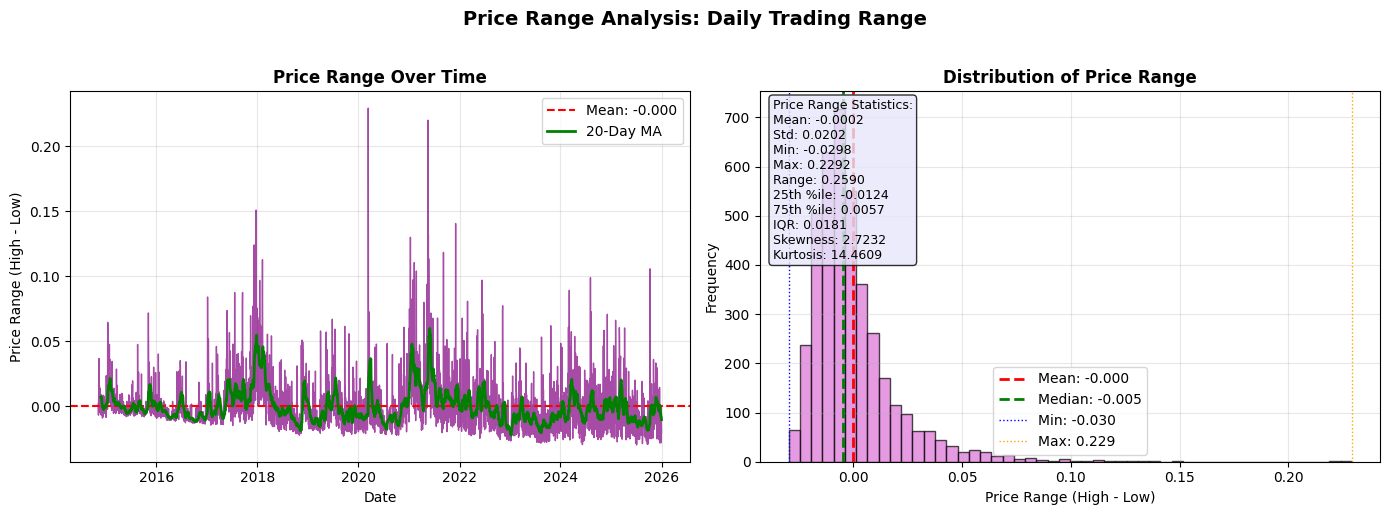

PRICE RANGE ANALYSIS
Average daily price range: -0.0002
Maximum daily range: 0.2292 (2020-03-12)
Minimum daily range: -0.0298 (2025-07-05)
Volatility of price range: 0.0202
Correlation with 20-day volatility: 0.1716

High volatility days (>75th percentile): 1010
Low volatility days (<25th percentile): 1010


In [80]:
# 2. Range of Price_Range Analysis
if 'Price_Range' in df_transformed.columns:
    # Calculate statistics
    price_range = df_transformed['Price_Range'].dropna()

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Time series plot of Price_Range
    ax1.plot(df_transformed.index, price_range, color='purple',
             linewidth=1, alpha=0.7)
    ax1.axhline(y=price_range.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {price_range.mean():.3f}')

    # Add rolling average
    if len(price_range) > 20:
        rolling_mean = price_range.rolling(window=20).mean()
        ax1.plot(df_transformed.index, rolling_mean, color='green',
                 linewidth=2, label='20-Day MA')

    ax1.set_title('Price Range Over Time', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price Range (High - Low)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Histogram with statistics
    counts, bins, patches = ax2.hist(price_range, bins=50, alpha=0.7,
                                     color='orchid', edgecolor='black')

    # Add vertical lines for statistics
    ax2.axvline(price_range.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {price_range.mean():.3f}')
    ax2.axvline(price_range.median(), color='green', linestyle='--',
                linewidth=2, label=f'Median: {price_range.median():.3f}')
    ax2.axvline(price_range.min(), color='blue', linestyle=':',
                linewidth=1, label=f'Min: {price_range.min():.3f}')
    ax2.axvline(price_range.max(), color='orange', linestyle=':',
                linewidth=1, label=f'Max: {price_range.max():.3f}')

    ax2.set_title('Distribution of Price Range',
                  fontweight='bold', fontsize=12)
    ax2.set_xlabel('Price Range (High - Low)')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Add statistics text
    range_stats = f"""Price Range Statistics:
Mean: {price_range.mean():.4f}
Std: {price_range.std():.4f}
Min: {price_range.min():.4f}
Max: {price_range.max():.4f}
Range: {price_range.max() - price_range.min():.4f}
25th %ile: {price_range.quantile(0.25):.4f}
75th %ile: {price_range.quantile(0.75):.4f}
IQR: {price_range.quantile(0.75) - price_range.quantile(0.25):.4f}
Skewness: {price_range.skew():.4f}
Kurtosis: {price_range.kurtosis():.4f}"""

    ax2.text(0.02, 0.98, range_stats, transform=ax2.transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

    plt.suptitle('Price Range Analysis: Daily Trading Range',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Additional analysis: Price Range vs Volatility
    print("="*60)
    print("PRICE RANGE ANALYSIS")
    print("="*60)
    print(f"Average daily price range: {price_range.mean():.4f}")
    print(
        f"Maximum daily range: {price_range.max():.4f} ({price_range.idxmax().date()})")
    print(
        f"Minimum daily range: {price_range.min():.4f} ({price_range.idxmin().date()})")
    print(f"Volatility of price range: {price_range.std():.4f}")

    # Check correlation with other volatility measures
    if 'Volatility_20' in df_transformed.columns:
        corr = price_range.corr(df_transformed['Volatility_20'].dropna())
        print(f"Correlation with 20-day volatility: {corr:.4f}")

    # Identify high and low volatility periods
    high_vol_days = price_range[price_range > price_range.quantile(0.75)]
    low_vol_days = price_range[price_range < price_range.quantile(0.25)]

    print(f"\nHigh volatility days (>75th percentile): {len(high_vol_days)}")
    print(f"Low volatility days (<25th percentile): {len(low_vol_days)}")

else:
    print("Price_Range column not found")
    # Check if we have High and Low columns to calculate it
    if all(col in df_transformed.columns for col in ['High', 'Low']):
        print("Calculating Price_Range from High and Low columns...")
        df_transformed['Price_Range'] = df_transformed['High'] - \
            df_transformed['Low']
        print("Price_Range created successfully")
        # Run the analysis again

## Bivariate Analysis

In [81]:
# Correlation matrix: Heatmap of all features
# Close vs Day_of_Week (box plots by weekday)



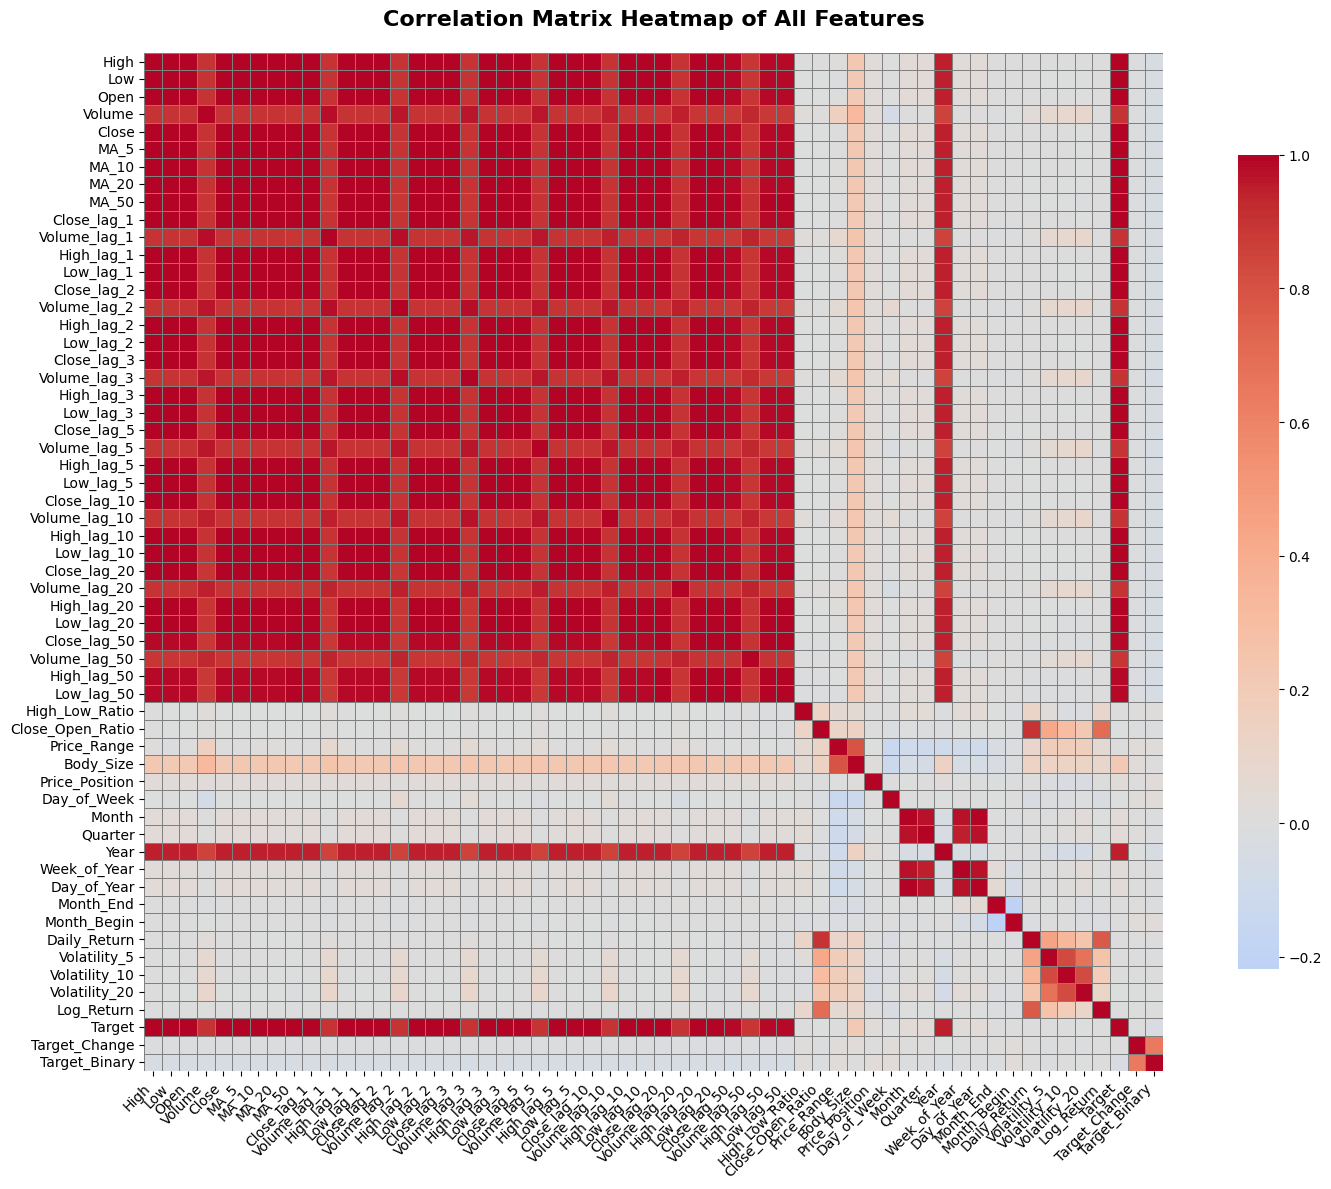

TOP 10 POSITIVE CORRELATIONS:
Close_lag_1          ↔ Open                : 1.000
MA_5                 ↔ Close_lag_2         : 1.000
MA_5                 ↔ High_lag_1          : 1.000
High_lag_2           ↔ MA_5                : 1.000
Close                ↔ High                : 1.000
High_lag_5           ↔ Close_lag_5         : 1.000
High_lag_3           ↔ Close_lag_3         : 1.000
Open                 ↔ High_lag_1          : 1.000
Close_lag_20         ↔ High_lag_20         : 1.000
Close_lag_1          ↔ High_lag_1          : 1.000

TOP 10 NEGATIVE CORRELATIONS:
Month_End            ↔ Month_Begin         : -0.219
Month_Begin          ↔ Month_End           : -0.219
Price_Range          ↔ Day_of_Week         : -0.134
Day_of_Week          ↔ Price_Range         : -0.134
Body_Size            ↔ Day_of_Week         : -0.123
Day_of_Week          ↔ Body_Size           : -0.123
Price_Range          ↔ Quarter             : -0.102
Quarter              ↔ Price_Range         : -0.102
Year         

In [82]:
# 1. Correlation Matrix Heatmap of All Features
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_cols = df_transformed.select_dtypes(
    include=[np.number]).columns.tolist()
correlation_data = df_transformed[numeric_cols]

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Create heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=False,  # Set to True to see values, but can be crowded
            cmap='coolwarm',
            center=0,
            square=True,
            cbar_kws={"shrink": 0.8},
            linewidths=0.5,
            linecolor='gray')

plt.title('Correlation Matrix Heatmap of All Features',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Show top correlations
print("TOP 10 POSITIVE CORRELATIONS:")
top_pos_corr = (corr_matrix.unstack()
                .sort_values(ascending=False)
                .drop_duplicates()
                .head(11))  # Top 10 + self-correlation
for (feat1, feat2), value in top_pos_corr.items():
    if feat1 != feat2:  # Exclude self-correlations
        print(f"{feat1:20} ↔ {feat2:20}: {value:.3f}")

print("\nTOP 10 NEGATIVE CORRELATIONS:")
top_neg_corr = (corr_matrix.unstack()
                .sort_values(ascending=True)
                .head(10))
for (feat1, feat2), value in top_neg_corr.items():
    print(f"{feat1:20} ↔ {feat2:20}: {value:.3f}")

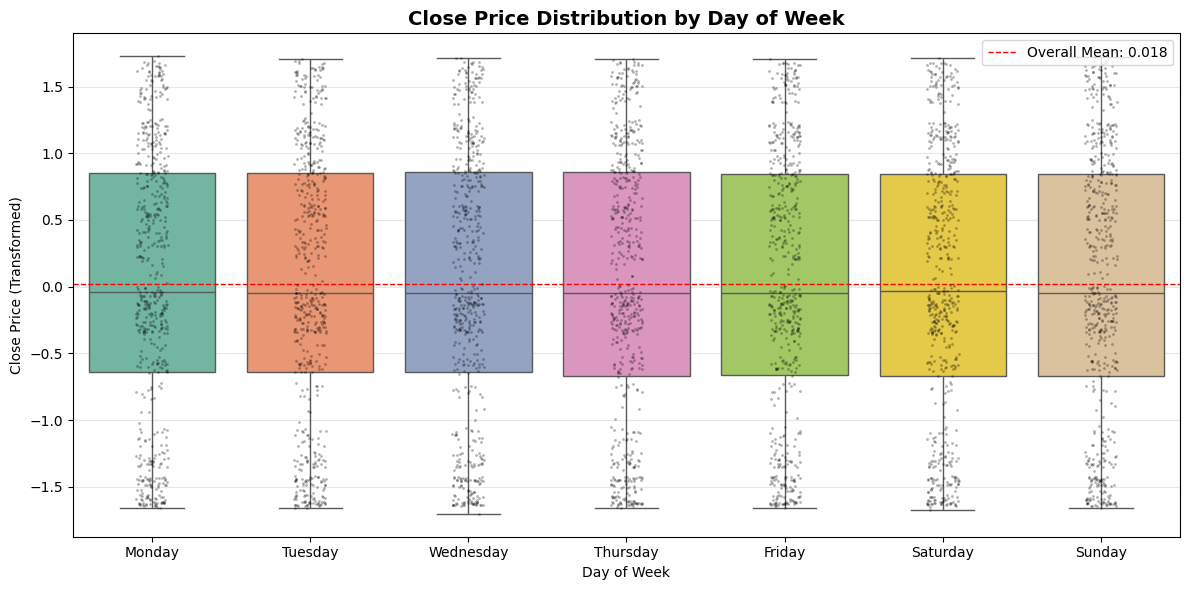

CLOSE PRICE STATISTICS BY DAY OF WEEK:
            mean    std  count
Day_Name                      
Friday     0.016  0.996    578
Monday     0.019  0.998    576
Saturday   0.017  0.997    577
Sunday     0.017  0.997    577
Thursday   0.018  0.997    579
Tuesday    0.019  0.998    575
Wednesday  0.021  0.998    578

STATISTICAL TEST FOR DAY-OF-WEEK EFFECT:
Kruskal-Wallis H-test: H = 0.009, p = 1.0000
❌ No significant difference between days


In [83]:
# 2. Close vs Day_of_Week (Box Plots by Weekday)
import seaborn as sns
import matplotlib.pyplot as plt

# Check if Day_of_Week column exists
if 'Day_of_Week' in df_transformed.columns:
    # Map day numbers to names
    day_names = ['Monday', 'Tuesday', 'Wednesday',
                 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # Create a copy with day names
    plot_data = df_transformed.copy()
    plot_data['Day_Name'] = plot_data['Day_of_Week'].map(
        lambda x: day_names[int(x)] if not pd.isna(x) else None)
    plot_data = plot_data.dropna(subset=['Day_Name', 'Close'])

    # Create box plot
    plt.figure(figsize=(12, 6))

    # Box plot
    sns.boxplot(x='Day_Name', y='Close', data=plot_data,
                order=day_names[:5] if plot_data['Day_of_Week'].max(
                ) < 5 else day_names,
                palette='Set2')

    # Add stripplot for individual points
    sns.stripplot(x='Day_Name', y='Close', data=plot_data,
                  order=day_names[:5] if plot_data['Day_of_Week'].max(
                  ) < 5 else day_names,
                  color='black', alpha=0.3, size=2, jitter=True)

    # Add mean line
    plt.axhline(y=plot_data['Close'].mean(), color='red', linestyle='--',
                linewidth=1, label=f"Overall Mean: {plot_data['Close'].mean():.3f}")

    plt.title('Close Price Distribution by Day of Week',
              fontsize=14, fontweight='bold')
    plt.xlabel('Day of Week')
    plt.ylabel('Close Price (Transformed)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Print statistics
    print("CLOSE PRICE STATISTICS BY DAY OF WEEK:")
    print("="*50)
    day_stats = plot_data.groupby('Day_Name')['Close'].agg([
        'mean', 'std', 'count'])
    print(day_stats.round(3))

    # Check for significant differences (ANOVA-like)
    from scipy import stats
    print("\n" + "="*50)
    print("STATISTICAL TEST FOR DAY-OF-WEEK EFFECT:")

    # Group data by day
    day_groups = [group['Close'].values for name,
                  group in plot_data.groupby('Day_Name')]

    if len(day_groups) >= 2:
        # Kruskal-Wallis test (non-parametric ANOVA)
        stat, p_value = stats.kruskal(*day_groups)
        print(f"Kruskal-Wallis H-test: H = {stat:.3f}, p = {p_value:.4f}")
        if p_value < 0.05:
            print("✅ Significant difference between days (p < 0.05)")
        else:
            print("❌ No significant difference between days")

else:
    print("Day_of_Week column not found in dataframe")
    print("Available columns:", list(df_transformed.columns)[:10], "...")

## Multivariate Analysis

In [84]:
# 3D scatter plot with color by Target_Binary
# Group similar trading days using K-means on features




Using features for 3D plot: ['Daily_Return', 'Volume', 'Price_Range']


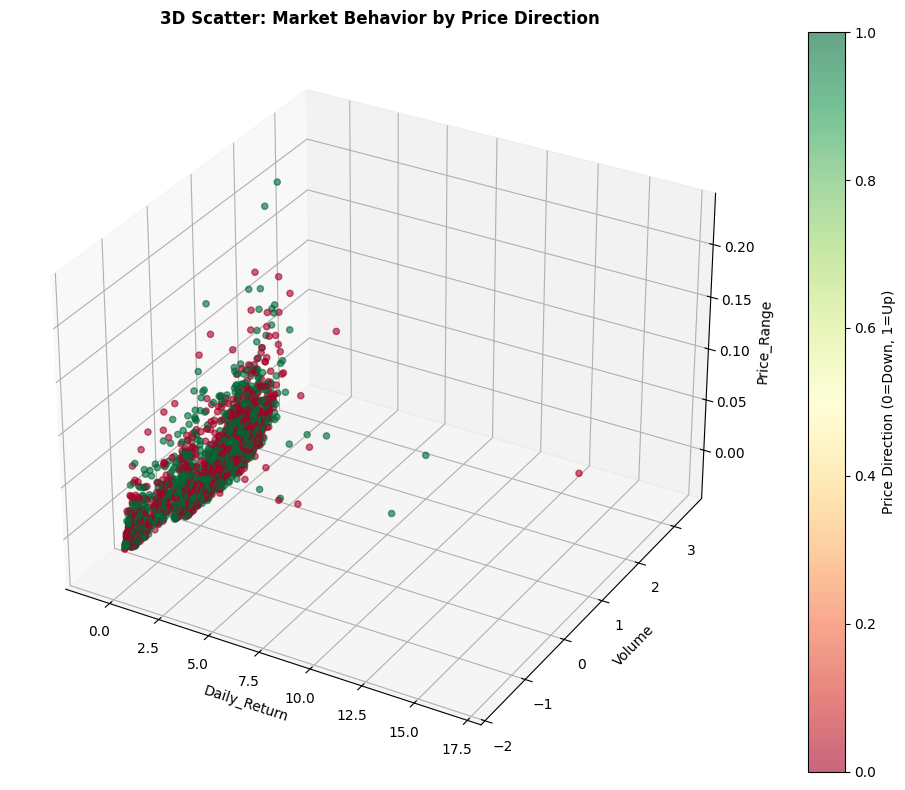

In [85]:
# 3D Scatter Plot with Color by Target_Binary - Using available columns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Check if we have at least 3 suitable columns
available_cols = df_transformed.columns.tolist()

# Try to find 3 meaningful features (adjust based on your actual columns)
if 'Daily_Return' in available_cols and 'Volume' in available_cols and 'Price_Range' in available_cols:
    features_3d = ['Daily_Return', 'Volume', 'Price_Range']
elif 'Close' in available_cols and 'Volume' in available_cols and 'Volatility_20' in available_cols:
    features_3d = ['Close', 'Volume', 'Volatility_20']
elif 'MA_5' in available_cols and 'MA_20' in available_cols and 'Volume' in available_cols:
    features_3d = ['MA_5', 'MA_20', 'Volume']
else:
    # Use first 3 numeric columns
    numeric_cols = df_transformed.select_dtypes(
        include=[np.number]).columns.tolist()
    features_3d = numeric_cols[:3] if len(numeric_cols) >= 3 else numeric_cols

print(f"Using features for 3D plot: {features_3d}")

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Drop rows with NaN in selected features
plot_data = df_transformed[features_3d + ['Target_Binary']].dropna()

# Scatter plot colored by Target_Binary (0=red, 1=green)
scatter = ax.scatter(plot_data[features_3d[0]],
                     plot_data[features_3d[1]],
                     plot_data[features_3d[2]],
                     c=plot_data['Target_Binary'],
                     cmap='RdYlGn',
                     alpha=0.6,
                     s=20)

ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])
ax.set_title('3D Scatter: Market Behavior by Price Direction',
             fontweight='bold')

# Add colorbar
plt.colorbar(scatter, label='Price Direction (0=Down, 1=Up)')
plt.tight_layout()
plt.show()

Clustering data shape: (4040, 3)

Cluster centers:
[[ 6.24948968e-01  6.63466545e-01 -1.81565060e-02]
 [-1.09164654e+00 -1.15995807e+00 -4.70927621e-02]
 [ 1.94341019e-03  3.04649532e-01  2.31537724e+01]]


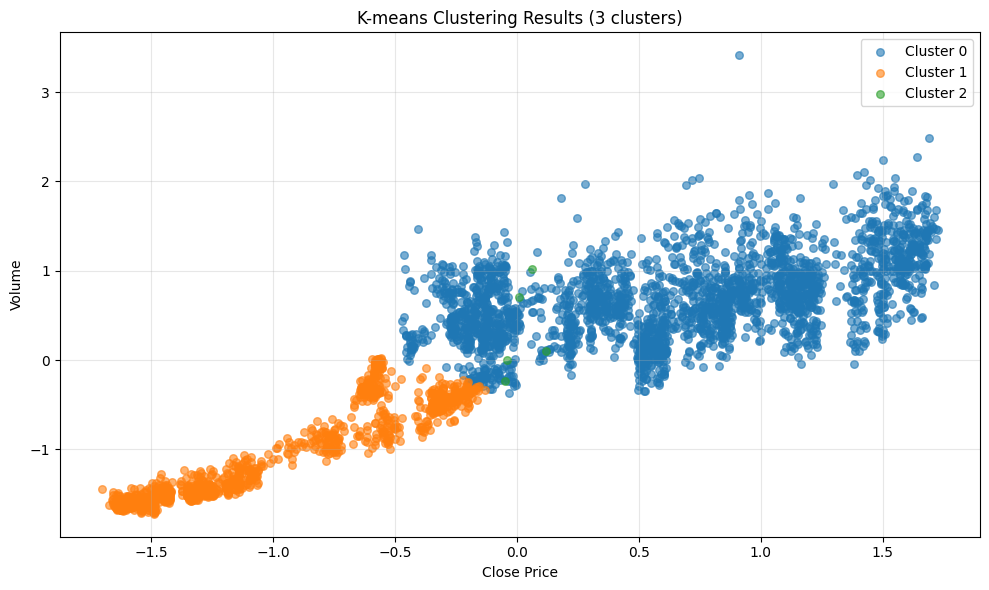

In [86]:
# SIMPLE K-means Clustering with what you definitely have
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use columns that you definitely created earlier
simple_features = ['Close', 'Volume', 'Daily_Return']  # These should exist
df_cluster = df_transformed[simple_features].dropna()

print(f"Clustering data shape: {df_cluster.shape}")

if len(df_cluster) > 10:  # Need enough data
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_cluster)

    # Apply K-means
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    df_cluster['Cluster'] = clusters

    print("\nCluster centers:")
    print(kmeans.cluster_centers_)

    # Simple visualization
    plt.figure(figsize=(10, 6))
    for cluster in range(3):
        cluster_data = df_cluster[df_cluster['Cluster'] == cluster]
        plt.scatter(cluster_data['Close'], cluster_data['Volume'],
                    alpha=0.6, s=30, label=f'Cluster {cluster}')

    plt.xlabel('Close Price')
    plt.ylabel('Volume')
    plt.title('K-means Clustering Results (3 clusters)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for clustering")

## Final Dataframe

In [87]:
df_transformed.tail()

,High,Low,Open,Volume,Close,MA_5,MA_10,MA_20,MA_50,Close_lag_1,...,Month_End,Month_Begin,Daily_Return,Volatility_5,Volatility_10,Volatility_20,Log_Return,Target,Target_Change,Target_Binary
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-28,1.406890,1.435045,1.421286,0.213161,1.421203,1.418519,1.421578,1.427682,1.448769,1.420879,...,1,0,0.000228,0.002157,0.006568,0.008558,0.000228,1.414476,-0.006727,0
2025-12-29,1.428819,1.428485,1.421636,1.076120,1.414476,1.417604,1.420649,1.425063,1.445617,1.421203,...,1,0,-0.004734,0.003114,0.003294,0.007924,-0.004745,1.426899,0.012424,1
2025-12-30,1.419381,1.428657,1.414876,0.818544,1.426899,1.419902,1.420731,1.423375,1.442503,1.414476,...,1,0,0.008783,0.004954,0.004427,0.008241,0.008745,1.418055,-0.008844,0
2025-12-31,1.417317,1.432488,1.427324,0.778340,1.418055,1.420302,1.419664,1.421018,1.439711,1.426899,...,1,0,-0.006198,0.006107,0.004783,0.008252,-0.006217,1.429780,0.011725,1
2026-01-01,1.414685,1.435088,1.418483,0.353914,1.429780,1.422083,1.419895,1.420290,1.437381,1.418055,...,0,1,0.008268,0.007041,0.005564,0.007968,0.008234,NaN,0.011495,1


In [88]:
print(df_transformed.columns.tolist())

['High', 'Low', 'Open', 'Volume', 'Close', 'MA_5', 'MA_10', 'MA_20', 'MA_50', 'Close_lag_1', 'Volume_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_2', 'Volume_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_3', 'Volume_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_5', 'Volume_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_10', 'Volume_lag_10', 'High_lag_10', 'Low_lag_10', 'Close_lag_20', 'Volume_lag_20', 'High_lag_20', 'Low_lag_20', 'Close_lag_50', 'Volume_lag_50', 'High_lag_50', 'Low_lag_50', 'High_Low_Ratio', 'Close_Open_Ratio', 'Price_Range', 'Body_Size', 'Price_Position', 'Day_of_Week', 'Month', 'Quarter', 'Year', 'Week_of_Year', 'Day_of_Year', 'Month_End', 'Month_Begin', 'Daily_Return', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Log_Return', 'Target', 'Target_Change', 'Target_Binary']


# Machine Learning Models

## ARIMA

ARIMA is a univariate time-series model, which means:

It models one time-dependent variable

It does not directly use multiple features like ML models (Random Forest, XGBoost, LSTM, etc.)

### Data Preparation

In [89]:
df_arima = df_transformed.copy()

In [92]:
df_arima.tail()

,High,Low,Open,Volume,Close,MA_5,MA_10,MA_20,MA_50,Close_lag_1,...,Month_End,Month_Begin,Daily_Return,Volatility_5,Volatility_10,Volatility_20,Log_Return,Target,Target_Change,Target_Binary
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-28,1.406890,1.435045,1.421286,0.213161,1.421203,1.418519,1.421578,1.427682,1.448769,1.420879,...,1,0,0.000228,0.002157,0.006568,0.008558,0.000228,1.414476,-0.006727,0
2025-12-29,1.428819,1.428485,1.421636,1.076120,1.414476,1.417604,1.420649,1.425063,1.445617,1.421203,...,1,0,-0.004734,0.003114,0.003294,0.007924,-0.004745,1.426899,0.012424,1
2025-12-30,1.419381,1.428657,1.414876,0.818544,1.426899,1.419902,1.420731,1.423375,1.442503,1.414476,...,1,0,0.008783,0.004954,0.004427,0.008241,0.008745,1.418055,-0.008844,0
2025-12-31,1.417317,1.432488,1.427324,0.778340,1.418055,1.420302,1.419664,1.421018,1.439711,1.426899,...,1,0,-0.006198,0.006107,0.004783,0.008252,-0.006217,1.429780,0.011725,1
2026-01-01,1.414685,1.435088,1.418483,0.353914,1.429780,1.422083,1.419895,1.420290,1.437381,1.418055,...,0,1,0.008268,0.007041,0.005564,0.007968,0.008234,NaN,0.011495,1


## LSTM

## PROPHET

## RANDOM FOREST